# 📊 Unemployment in India — Professional Data Analysis & Multi-Model Prediction
---
| | |
|---|---|
| **Author** | Data Science Lab |
| **Dataset 1** | `Unemployment_in_India.csv` — 768 records · 28 states/UTs · Rural & Urban breakdown |
| **Dataset 2** | `Unemployment_Rate_upto_11_2020.csv` — 267 records · Jan–Nov 2020 · with geo-coordinates |
| **Period** | May 2019 – Nov 2020 (includes COVID-19 lockdown shock) |
| **Target** | `Estimated Unemployment Rate (%)` |
| **Models** | 10 algorithms — Linear → Tree-based → Gradient Boosting → XGBoost → LightGBM |

---
## Table of Contents
1. [Library Imports & Global Settings](#1)
2. [Data Loading & Cleaning](#2)
3. [Dataset Overview & Missing Value Analysis](#3)
4. [National Unemployment Trend Over Time](#4)
5. [Rural vs Urban Unemployment Over Time](#5)
6. [COVID-19 Impact Analysis](#6)
7. [State-wise Unemployment — Bar & Box Plots](#7)
8. [Zone-wise Distribution (Dataset 2)](#8)
9. [Scatter Analysis — Feature Relationships](#9)
10. [Distribution Analysis — Histograms & KDE](#10)
11. [Violin & Strip Overlay Plots](#11)
12. [Pair Plot — All Feature Combinations](#12)
13. [Correlation Heatmap & Region×Month Heatmap](#13)
14. [Feature Engineering](#14)
15. [Train / Test Split & Scaling](#15)
16. [Training 10 Models — Cross-Validated Comparison](#16)
17. [Model Performance Visualisation](#17)
18. [Best Model — Hyperparameter Tuning (GridSearchCV)](#18)
19. [Final Model Evaluation on Test Set](#19)
20. [Actual vs Predicted & Residual Analysis](#20)
21. [Feature Importance & SHAP-style Analysis](#21)
22. [Learning Curves](#22)
23. [Prediction Error Distribution](#23)
24. [Comprehensive Model Summary Table](#24)
25. [Conclusions](#25)

---
## 1. Library Imports & Global Settings <a id='1'></a>

All libraries are imported in one place. We configure a consistent, publication-quality visual theme across all plots.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from pathlib import Path

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.dpi': 130,'figure.facecolor': 'white','axes.titlesize': 13,'axes.labelsize': 11,'xtick.labelsize': 9,
                     'ytick.labelsize': 9,'legend.fontsize': 9,'axes.spines.top': False,'axes.spines.right': False,})
PALETTE = 'Set2'
ACCENT  = '#2563EB'
SEED    = 42


---
## 2. Data Loading & Cleaning <a id='2'></a>

Both datasets are loaded, column names are normalised (whitespace stripped), the `Date` column is parsed to `datetime`, and columns are renamed to clean, snake_case identifiers. A Frequency column inconsistency (`'Monthly'` vs `' Monthly'`) is also fixed.

In [2]:
BASE_DIR = Path.cwd().parent

file_path  = BASE_DIR / 'Datasets' / 'Unemployment in India.csv'
file_path2 = BASE_DIR / 'Datasets' / 'Unemployment_Rate_upto_11_2020.csv'

df  = pd.read_csv(file_path)
df2 = pd.read_csv(file_path2)

for frame in [df, df2]:
    frame.columns = frame.columns.str.strip()

RENAME = {
    'Estimated Unemployment Rate (%)':      'Unemployment_Rate',
    'Estimated Employed':                   'Employed',
    'Estimated Labour Participation Rate (%)': 'LPR',
}
df.rename(columns=RENAME, inplace=True)
df2.rename(columns={**RENAME, 'Region.1': 'Zone'}, inplace=True)

df['Date']  = pd.to_datetime(df['Date'].str.strip(),  dayfirst=True, errors='coerce')
df2['Date'] = pd.to_datetime(df2['Date'].str.strip(), dayfirst=True, errors='coerce')

df['Frequency']  = df['Frequency'].str.strip()
df2['Frequency'] = df2['Frequency'].str.strip()

df['Month']  = df['Date'].dt.month
df['Year']   = df['Date'].dt.year
df['Quarter']= df['Date'].dt.quarter
df['YM']     = df['Date'].dt.to_period('M').astype(str)

print(f'Dataset 1 shape  : {df.shape}')
print(f'Dataset 2 shape  : {df2.shape}')
print(f'Date range (df)  : {df["Date"].min().date()}  →  {df["Date"].max().date()}')
print(f'Date range (df2) : {df2["Date"].min().date()} →  {df2["Date"].max().date()}')
df.head(10)

Dataset 1 shape  : (768, 11)
Dataset 2 shape  : (267, 9)
Date range (df)  : 2019-05-31  →  2020-06-30
Date range (df2) : 2020-01-31 →  2020-10-31


,Region,Date,Frequency,Unemployment_Rate,Employed,LPR,Area,Month,Year,Quarter,YM
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,5.0,2019.0,2.0,2019-05
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,6.0,2019.0,2.0,2019-06
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,7.0,2019.0,3.0,2019-07
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,8.0,2019.0,3.0,2019-08
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,9.0,2019.0,3.0,2019-09
5,Andhra Pradesh,2019-10-31,Monthly,3.52,12017412.0,43.01,Rural,10.0,2019.0,4.0,2019-10
6,Andhra Pradesh,2019-11-30,Monthly,4.12,11397681.0,41.00,Rural,11.0,2019.0,4.0,2019-11
7,Andhra Pradesh,2019-12-31,Monthly,4.38,12528395.0,45.14,Rural,12.0,2019.0,4.0,2019-12
8,Andhra Pradesh,2020-01-31,Monthly,4.84,12016676.0,43.46,Rural,1.0,2020.0,1.0,2020-01
9,Andhra Pradesh,2020-02-29,Monthly,5.91,11723617.0,42.83,Rural,2.0,2020.0,1.0,2020-02


---
## 3. Dataset Overview & Missing Value Analysis <a id='3'></a>

We inspect data types, check for missing values, and review the statistical summary of all numeric variables.

In [3]:
print('── Column Data Types ──────────────────────────────')
print(df.dtypes)
print()
print('── Area Distribution ──────────────────────────────')
print(df['Area'].value_counts())
print()
print('── Unique States / UTs ────────────────────────────')
print(sorted([r for r in df['Region'].unique() if isinstance(r, str)]))

── Column Data Types ──────────────────────────────
Region                          str
Date                 datetime64[us]
Frequency                       str
Unemployment_Rate           float64
Employed                    float64
LPR                         float64
Area                            str
Month                       float64
Year                        float64
Quarter                     float64
YM                              str
dtype: object

── Area Distribution ──────────────────────────────
Area
Urban    381
Rural    359
Name: count, dtype: int64

── Unique States / UTs ────────────────────────────
['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


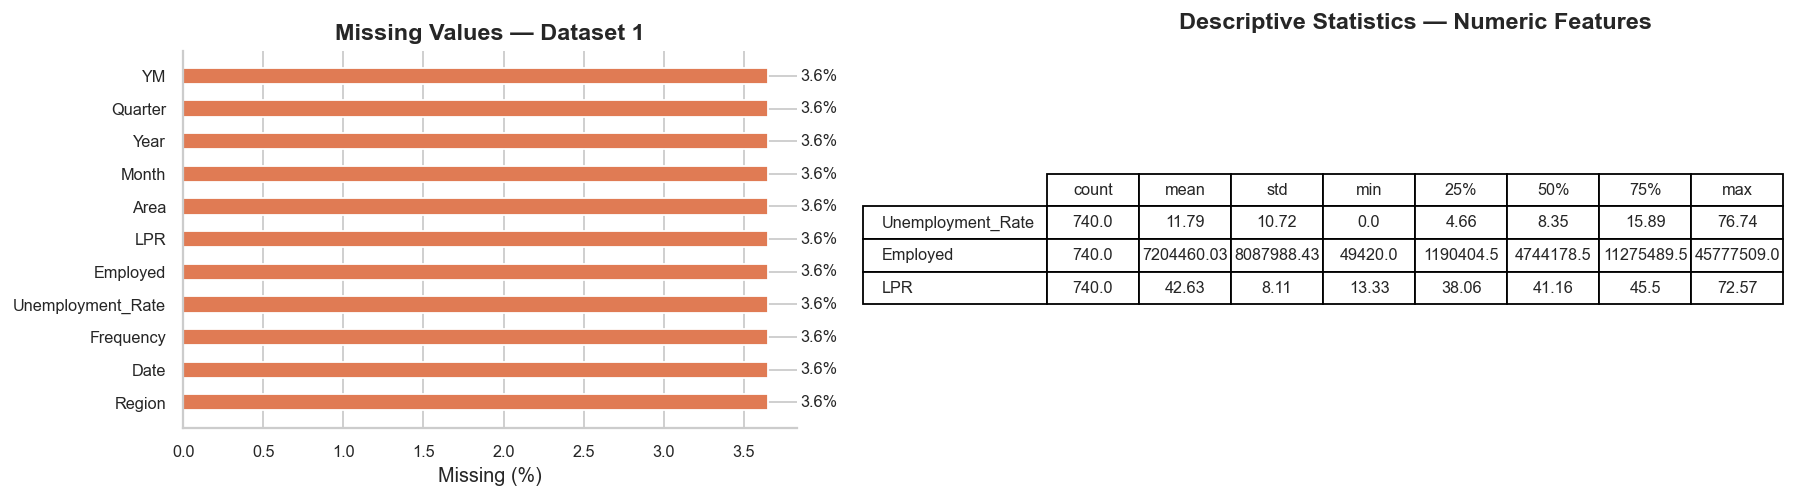

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(2)
miss_df = pd.DataFrame({'Missing Count': miss, 'Missing %': miss_pct})
miss_df = miss_df[miss_df['Missing Count'] > 0]

bars = axes[0].barh(miss_df.index, miss_df['Missing %'],
                    color='#E07B54', edgecolor='white', height=0.5)
for bar, val in zip(bars, miss_df['Missing %']):
    axes[0].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9)
axes[0].set_title('Missing Values — Dataset 1', fontweight='bold')
axes[0].set_xlabel('Missing (%)')

desc = df[['Unemployment_Rate','Employed','LPR']].describe().T
axes[1].axis('off')
tbl = axes[1].table(
    cellText=desc.round(2).values,
    rowLabels=desc.index,
    colLabels=desc.columns,
    cellLoc='center', loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.6)
axes[1].set_title('Descriptive Statistics — Numeric Features', fontweight='bold', pad=12)

plt.tight_layout()
plt.show()

In [5]:
df[['Unemployment_Rate', 'Employed', 'LPR']].describe().round(2)

,Unemployment_Rate,Employed,LPR
count,740.00,740.00,740.00
mean,11.79,7204460.03,42.63
std,10.72,8087988.43,8.11
min,0.00,49420.00,13.33
25%,4.66,1190404.50,38.06
50%,8.35,4744178.50,41.16
75%,15.89,11275489.50,45.50
max,76.74,45777509.00,72.57


**Key observations:**
- `Area` has **28 missing rows** (3.6 %) — these are national/aggregate rows without a Rural/Urban label; we retain them for time-series analysis but drop them for Area-stratified plots.
- `Unemployment_Rate` ranges from **0 % to 76.74 %** — the extreme upper values correspond to the April–May 2020 COVID lockdown.
- Median unemployment (8.35 %) is well below the mean (11.79 %), confirming a **right-skewed distribution** driven by the lockdown spike.

---
## 4. National Unemployment Trend Over Time <a id='4'></a>

The monthly national average unemployment rate is plotted with a shaded confidence band and annotated pandemic event markers.

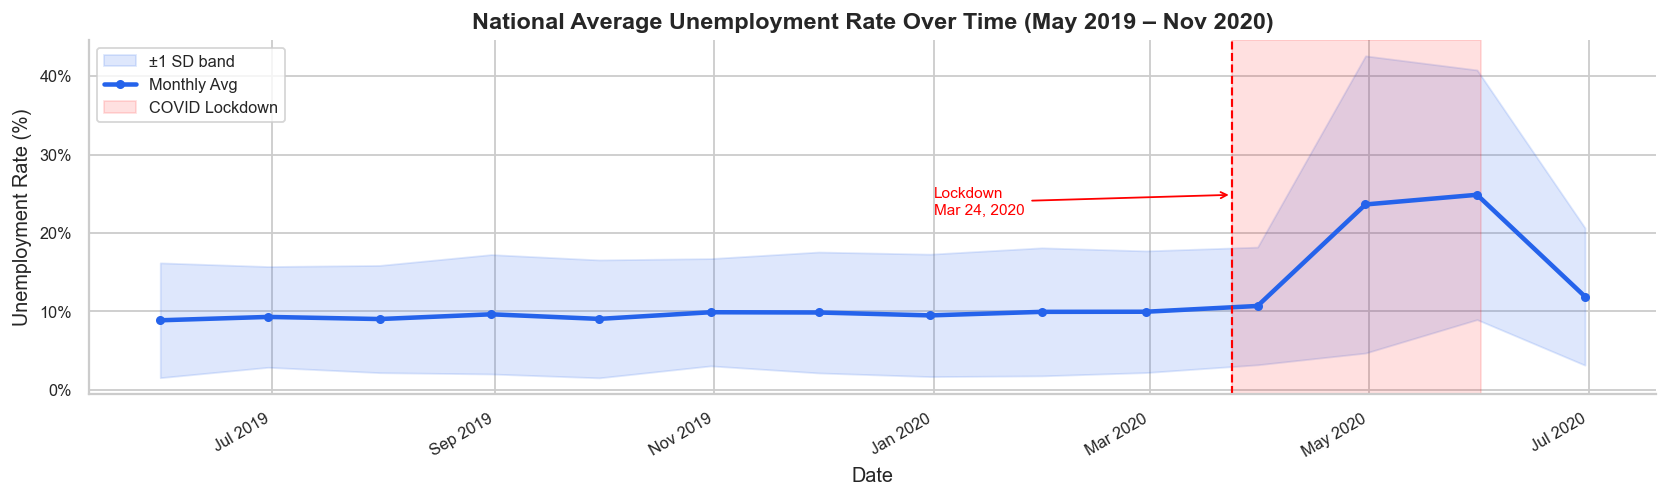

In [6]:
national = df.groupby('Date')['Unemployment_Rate'].agg(['mean','std']).reset_index()
national.columns = ['Date','Mean','Std']

fig, ax = plt.subplots(figsize=(13, 4))

ax.fill_between(national['Date'],
                national['Mean'] - national['Std'],
                national['Mean'] + national['Std'],
                alpha=0.15, color=ACCENT, label='±1 SD band')
ax.plot(national['Date'], national['Mean'],
        color=ACCENT, linewidth=2.5, marker='o', markersize=4, label='Monthly Avg')

import matplotlib.dates as mdates
lockdown_start = pd.Timestamp('2020-03-24')
lockdown_end   = pd.Timestamp('2020-06-01')
ax.axvspan(lockdown_start, lockdown_end, alpha=0.12, color='red', label='COVID Lockdown')
ax.axvline(lockdown_start, color='red', linestyle='--', linewidth=1.2)
ax.annotate('Lockdown\nMar 24, 2020', xy=(lockdown_start, national['Mean'].max()),
            xytext=(pd.Timestamp('2020-01-01'), national['Mean'].max() * 0.9),
            arrowprops=dict(arrowstyle='->', color='red'),
            color='red', fontsize=8.5)

ax.set_title('National Average Unemployment Rate Over Time (May 2019 – Nov 2020)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Unemployment Rate (%)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

The shaded band shows ±1 standard deviation — the enormous spread during April–May 2020 signals **extreme heterogeneity** across states during lockdown. Some states hit near 75 % while others remained below 20 %.

---
## 5. Rural vs Urban Unemployment Over Time <a id='5'></a>

Splitting the trend by `Area` reveals whether rural and urban populations experienced the COVID shock differently.

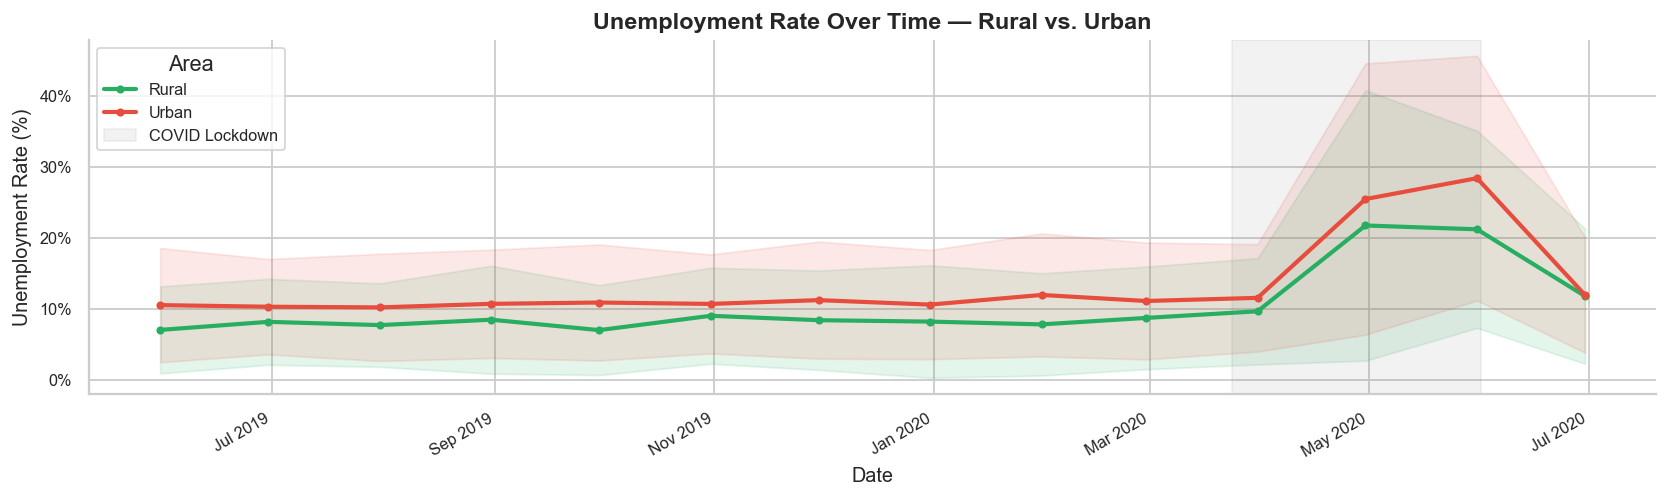

In [7]:
area_ts = (
    df.dropna(subset=['Area'])
      .groupby(['Date','Area'])['Unemployment_Rate']
      .agg(['mean','std'])
      .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 4))
colors_area = {'Rural': '#27AE60', 'Urban': '#E74C3C'}

for area, grp in area_ts.groupby('Area'):
    col = colors_area[area]
    ax.fill_between(grp['Date'], grp['mean'] - grp['std'], grp['mean'] + grp['std'],
                    alpha=0.12, color=col)
    ax.plot(grp['Date'], grp['mean'], color=col, linewidth=2.3,
            marker='o', markersize=3.5, label=area)

ax.axvspan(pd.Timestamp('2020-03-24'), pd.Timestamp('2020-06-01'),
           alpha=0.1, color='grey', label='COVID Lockdown')
ax.set_title('Unemployment Rate Over Time — Rural vs. Urban', fontweight='bold', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Unemployment Rate (%)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')
ax.legend(title='Area')
plt.tight_layout()
plt.show()

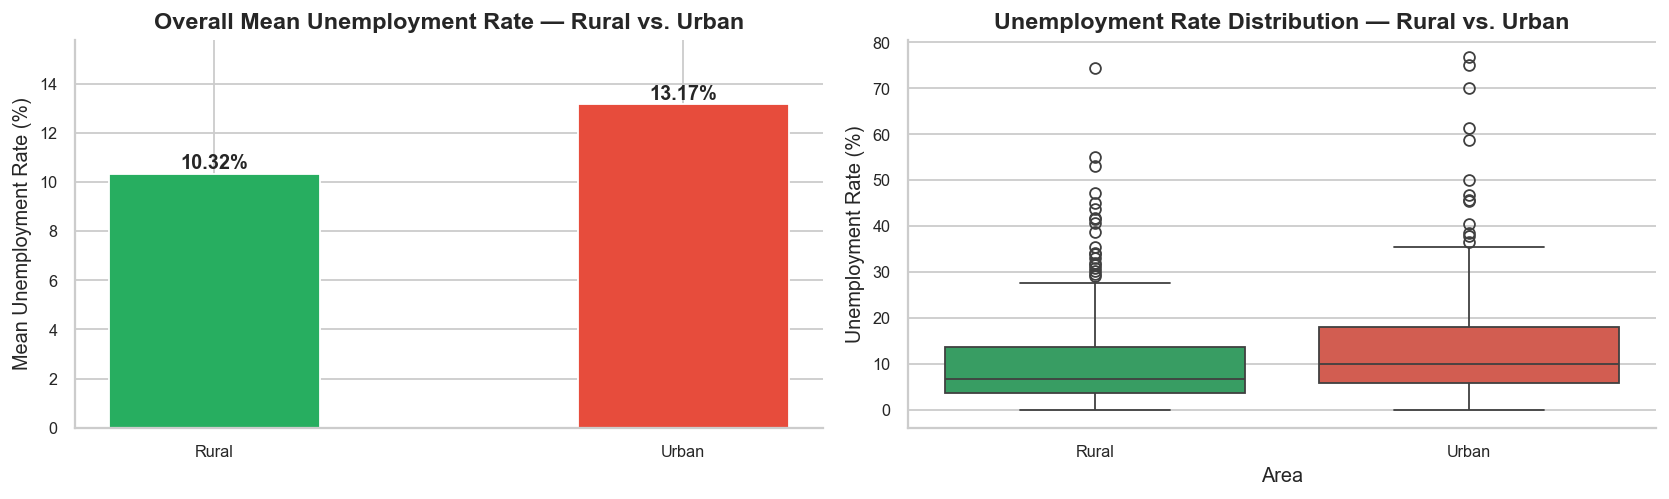

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

area_overall = df.dropna(subset=['Area']).groupby('Area')['Unemployment_Rate'].mean()
bars = axes[0].bar(area_overall.index, area_overall.values,
                   color=[colors_area[a] for a in area_overall.index],
                   edgecolor='white', width=0.45)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{bar.get_height():.2f}%', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Overall Mean Unemployment Rate — Rural vs. Urban', fontweight='bold')
axes[0].set_ylabel('Mean Unemployment Rate (%)')
axes[0].set_ylim(0, area_overall.max() * 1.2)

sns.boxplot(x='Area', y='Unemployment_Rate', data=df.dropna(subset=['Area']),
            palette=colors_area, order=['Rural','Urban'], ax=axes[1])
axes[1].set_title('Unemployment Rate Distribution — Rural vs. Urban', fontweight='bold')
axes[1].set_ylabel('Unemployment Rate (%)')

plt.tight_layout()
plt.show()

**Urban unemployment (mean ≈ 14 %)** consistently exceeds **Rural (mean ≈ 9 %)**. Urban areas have a wider distribution with higher variance, partly due to the service-sector-heavy composition of city economies that are more sensitive to lockdown restrictions.

## 6. COVID-19 Impact Analysis <a id='6'></a>

We isolate the Pre-COVID (Jan–Mar 2020), During-COVID (Apr–Jun 2020), and Post-COVID (Jul–Nov 2020) periods to quantify the shock magnitude.

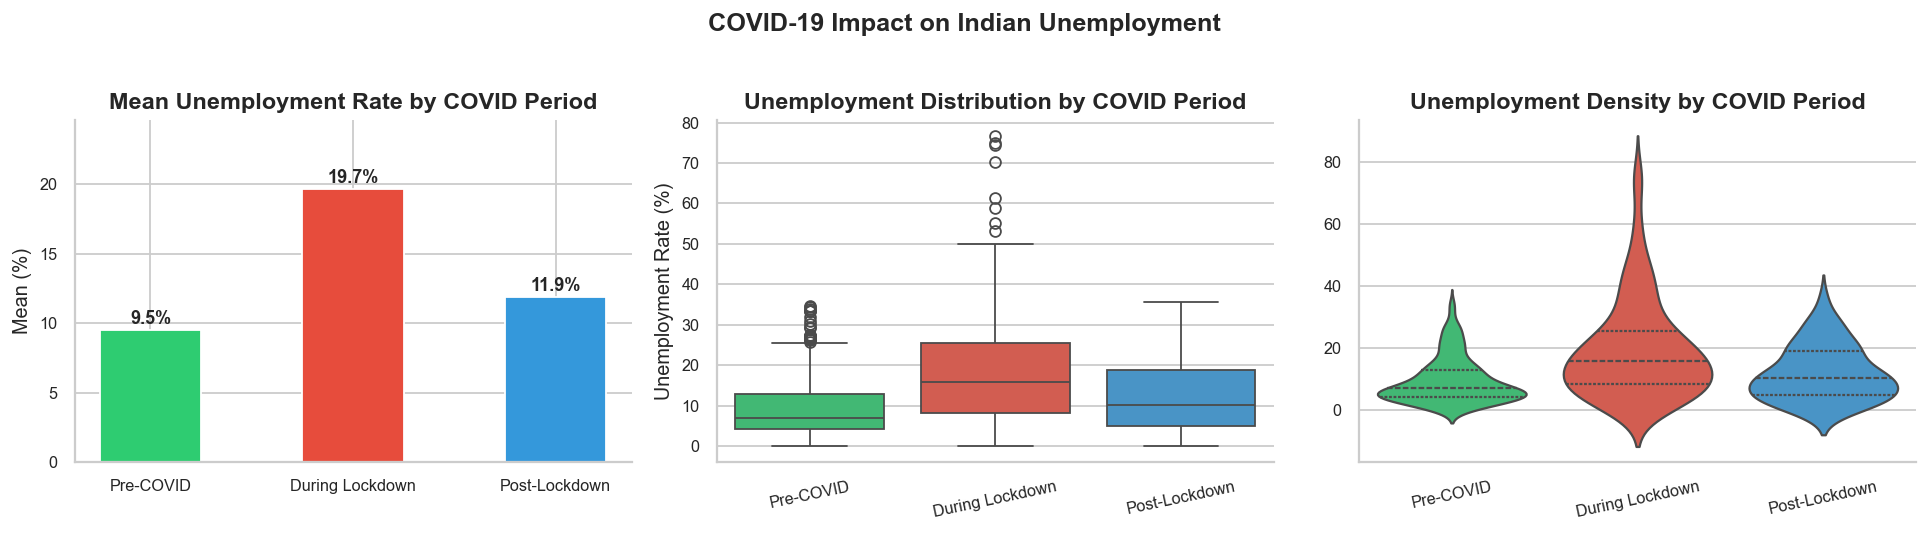

In [9]:
def covid_label(d):
    if d < pd.Timestamp('2020-03-24'): return 'Pre-COVID'
    elif d <= pd.Timestamp('2020-06-01'): return 'During Lockdown'
    else: return 'Post-Lockdown'

df['COVID_Period'] = df['Date'].apply(covid_label)
period_order = ['Pre-COVID', 'During Lockdown', 'Post-Lockdown']
period_colors = {'Pre-COVID': '#2ECC71', 'During Lockdown': '#E74C3C', 'Post-Lockdown': '#3498DB'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

covid_mean = df.groupby('COVID_Period')['Unemployment_Rate'].mean().reindex(period_order)
bars = axes[0].bar(covid_mean.index, covid_mean.values,
                   color=[period_colors[p] for p in period_order],
                   edgecolor='white', width=0.5)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                 f'{bar.get_height():.1f}%', ha='center', fontweight='bold', fontsize=10)
axes[0].set_title('Mean Unemployment Rate by COVID Period', fontweight='bold')
axes[0].set_ylabel('Mean (%)')
axes[0].set_ylim(0, covid_mean.max() * 1.25)

sns.boxplot(x='COVID_Period', y='Unemployment_Rate', data=df,
            order=period_order,
            palette=period_colors, ax=axes[1])
axes[1].set_title('Unemployment Distribution by COVID Period', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Unemployment Rate (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=12)

sns.violinplot(x='COVID_Period', y='Unemployment_Rate', data=df,
               order=period_order,
               palette=period_colors, inner='quartile', ax=axes[2])
axes[2].set_title('Unemployment Density by COVID Period', fontweight='bold')
axes[2].set_xlabel('')
axes[2].set_ylabel('')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=12)

plt.suptitle('COVID-19 Impact on Indian Unemployment', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

During the lockdown period, mean unemployment **nearly tripled** vs the pre-COVID baseline. The violin plot shows the "During Lockdown" distribution is highly multi-modal — different states were hit with very different intensity depending on their economic composition.

---
## 7. State-wise Unemployment — Bar & Box Plots <a id='7'></a>

We rank all states by their average unemployment rate and visualise both the ranking and within-state variability.

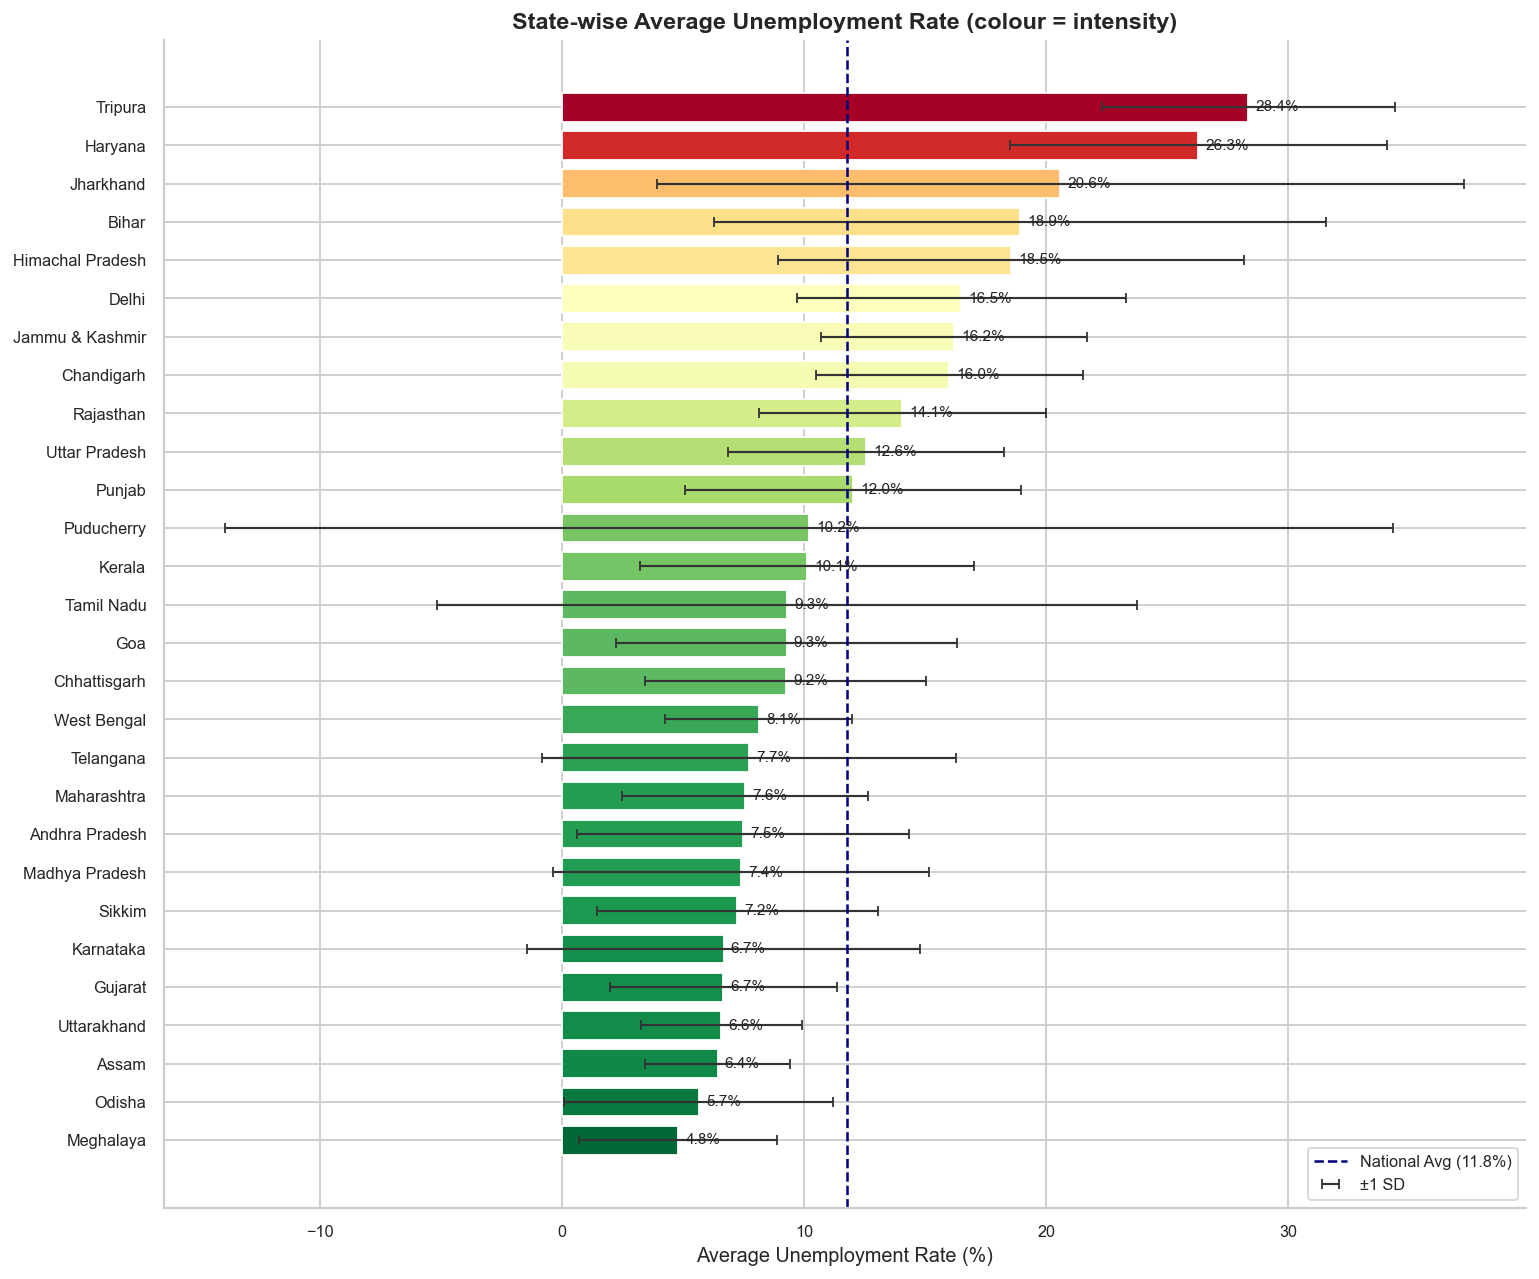

In [10]:
state_stats = df.groupby('Region')['Unemployment_Rate'].agg(['mean','std','min','max']).sort_values('mean')

fig, ax = plt.subplots(figsize=(12, 10))
cmap = plt.cm.RdYlGn_r
norm_vals = (state_stats['mean'] - state_stats['mean'].min()) / (state_stats['mean'].max() - state_stats['mean'].min())
bar_colors = [cmap(v) for v in norm_vals]

bars = ax.barh(state_stats.index, state_stats['mean'], color=bar_colors,
               edgecolor='white', height=0.75)
ax.errorbar(state_stats['mean'], range(len(state_stats)),
            xerr=state_stats['std'], fmt='none', color='#333', elinewidth=1.2,
            capsize=3, label='±1 SD')

for i, (bar, val) in enumerate(zip(bars, state_stats['mean'])):
    ax.text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=8.5)

nat_mean = df['Unemployment_Rate'].mean()
ax.axvline(nat_mean, color='navy', linestyle='--', linewidth=1.4, label=f'National Avg ({nat_mean:.1f}%)')

ax.set_title('State-wise Average Unemployment Rate (colour = intensity)', fontweight='bold', fontsize=13)
ax.set_xlabel('Average Unemployment Rate (%)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

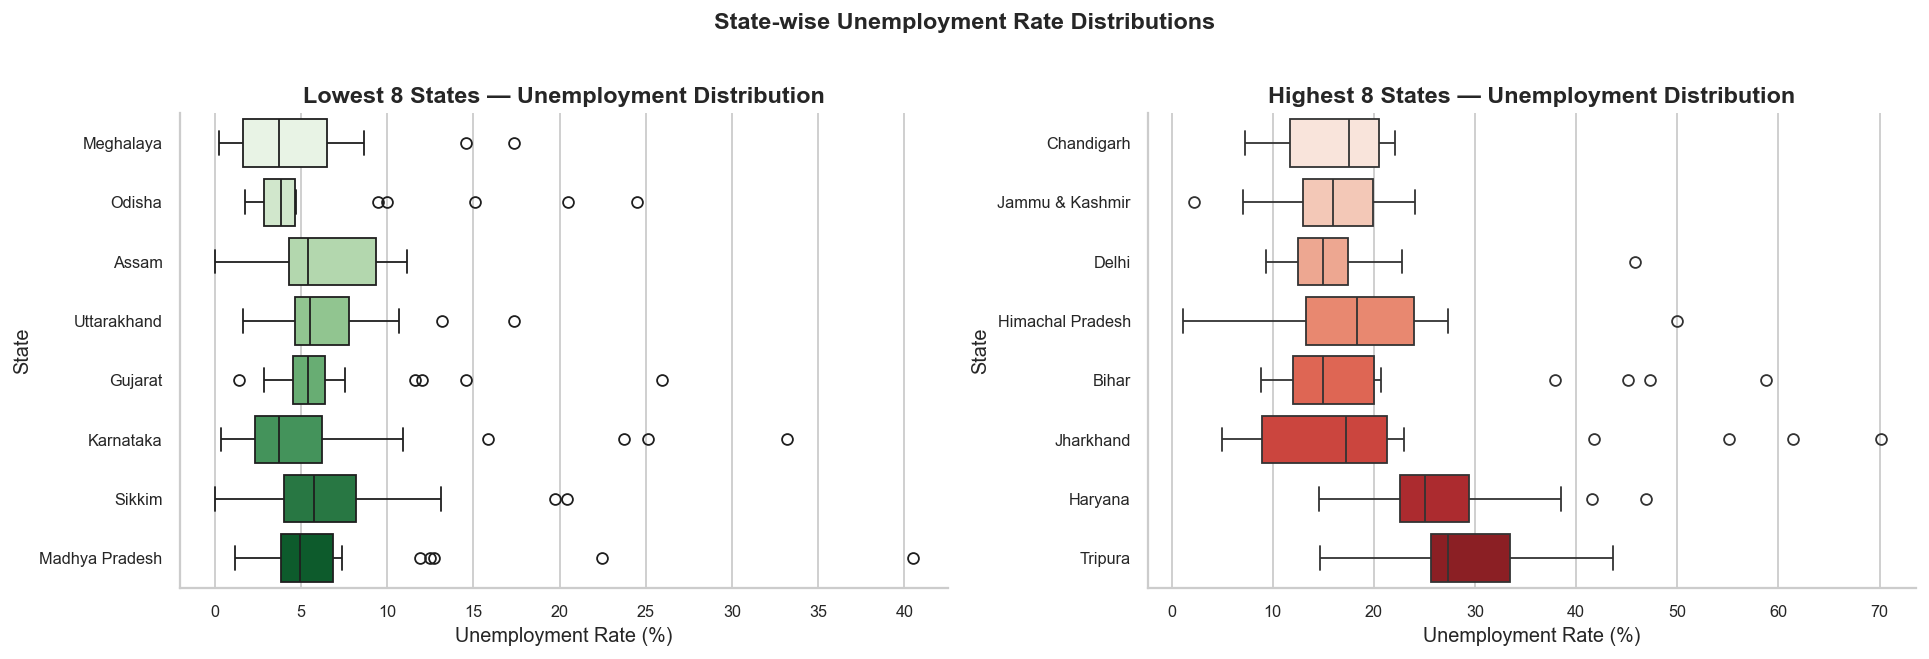

In [11]:
top_states    = state_stats.tail(8).index.tolist()
bottom_states = state_stats.head(8).index.tolist()
selected = bottom_states + top_states

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=False)

for ax, states, title, pal in [
    (axes[0], bottom_states, 'Lowest 8 States — Unemployment Distribution', 'Greens'),
    (axes[1], top_states,    'Highest 8 States — Unemployment Distribution', 'Reds')
]:
    sub = df[df['Region'].isin(states)]
    order = df[df['Region'].isin(states)].groupby('Region')['Unemployment_Rate'].mean().sort_values().index
    sns.boxplot(x='Unemployment_Rate', y='Region', data=sub,
                order=order, palette=pal, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Unemployment Rate (%)')
    ax.set_ylabel('State')

plt.suptitle('State-wise Unemployment Rate Distributions', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Tripura, Haryana, and Himachal Pradesh** consistently show the widest error bars, meaning their unemployment swings dramatically (likely both seasonally and due to COVID). **Meghalaya, Odisha, and Assam** have the narrowest distributions — stable, low-unemployment economies.

---
## 8. Zone-wise Distribution (Dataset 2) <a id='8'></a>

Dataset 2 provides a geographic zone classification (`North`, `South`, `East`, `West`, `Northeast`). We explore how unemployment differs across zones.

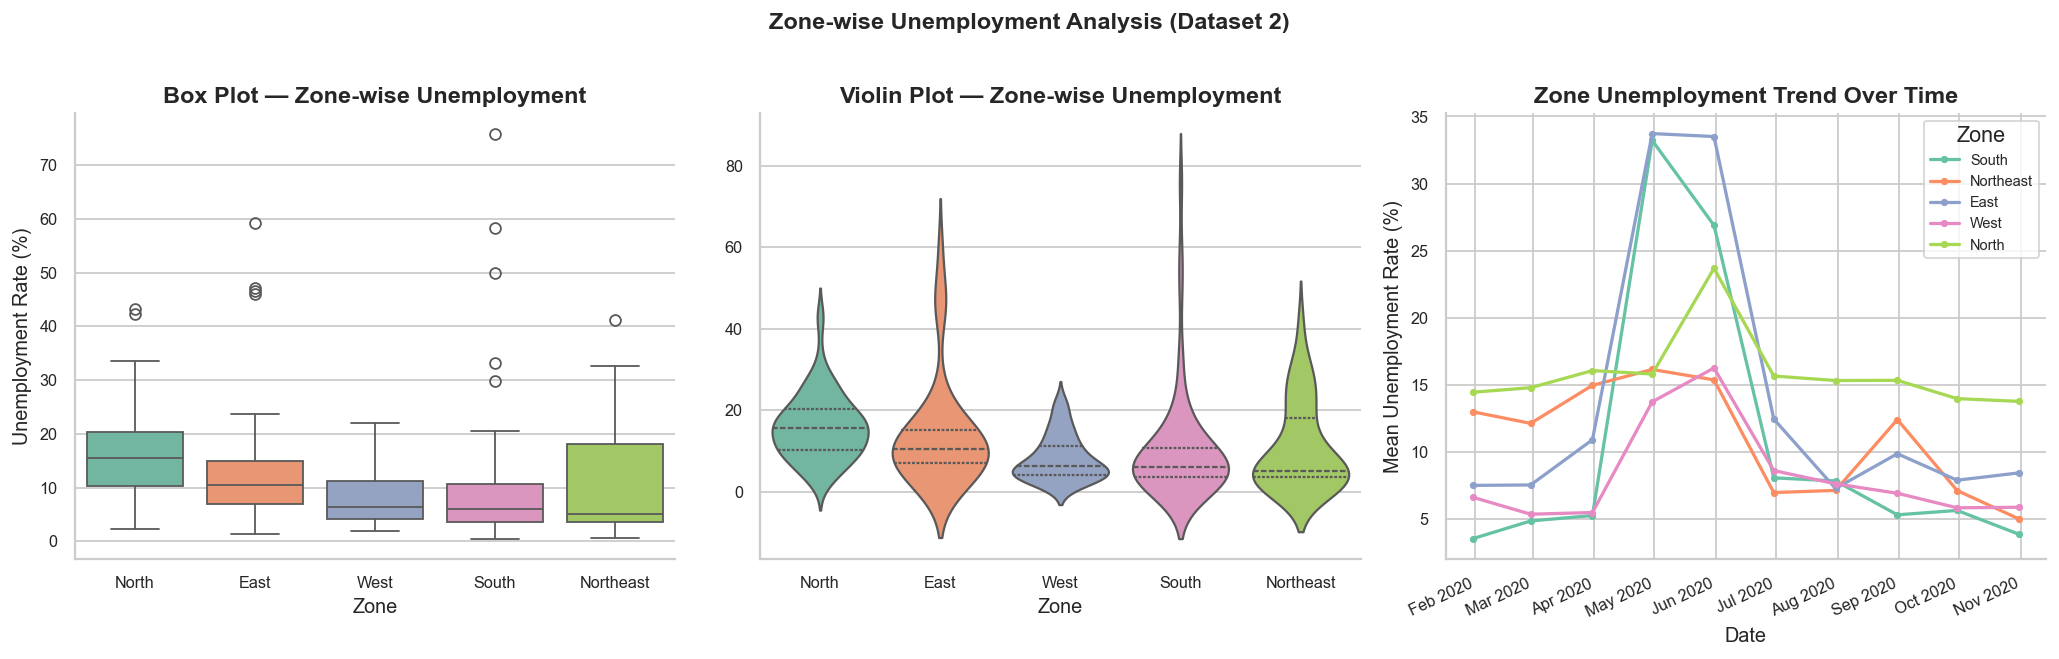

In [12]:
zone_order = df2.groupby('Zone')['Unemployment_Rate'].median().sort_values(ascending=False).index

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(x='Zone', y='Unemployment_Rate', data=df2, palette=PALETTE,
            order=zone_order, ax=axes[0])
axes[0].set_title('Box Plot — Zone-wise Unemployment', fontweight='bold')
axes[0].set_xlabel('Zone')
axes[0].set_ylabel('Unemployment Rate (%)')

sns.violinplot(x='Zone', y='Unemployment_Rate', data=df2, palette=PALETTE,
               inner='quartile', order=zone_order, ax=axes[1])
axes[1].set_title('Violin Plot — Zone-wise Unemployment', fontweight='bold')
axes[1].set_xlabel('Zone')
axes[1].set_ylabel('')

zone_ts = df2.groupby(['Date','Zone'])['Unemployment_Rate'].mean().reset_index()
for zone in df2['Zone'].unique():
    sub = zone_ts[zone_ts['Zone']==zone].sort_values('Date')
    axes[2].plot(sub['Date'], sub['Unemployment_Rate'], linewidth=1.8,
                 marker='o', markersize=3, label=zone)
axes[2].set_title('Zone Unemployment Trend Over Time', fontweight='bold')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Mean Unemployment Rate (%)')
axes[2].legend(title='Zone', fontsize=8)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[2].get_xticklabels(), rotation=25, ha='right')

plt.suptitle('Zone-wise Unemployment Analysis (Dataset 2)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 9. Scatter Analysis — Feature Relationships <a id='9'></a>

Pairwise scatter plots expose the relationship between `Unemployment_Rate`, `LPR`, and `Employed`, coloured by `Area`.

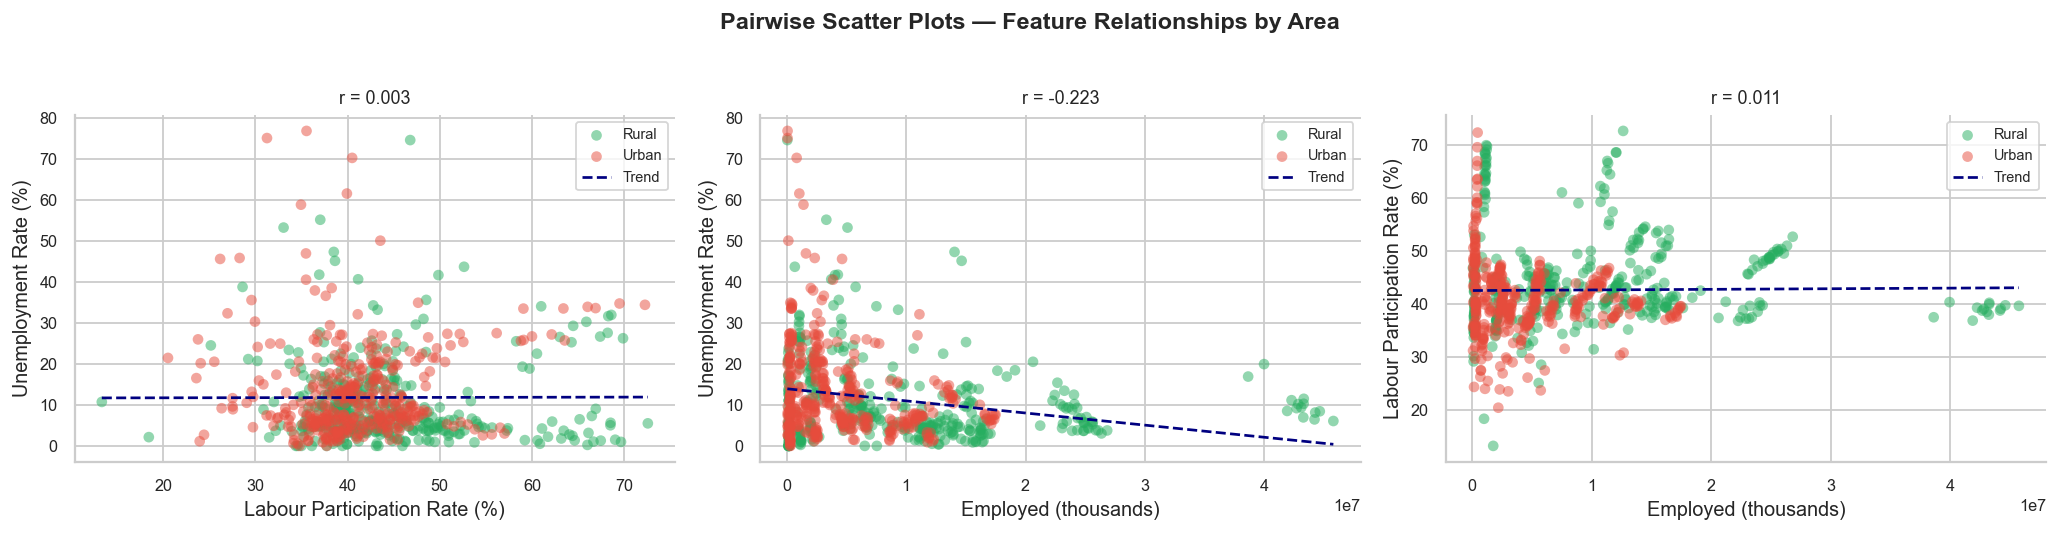

In [13]:
df_clean = df.dropna(subset=['Area']).copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

pairs = [
    ('LPR',      'Unemployment_Rate', 'Labour Participation Rate (%)', 'Unemployment Rate (%)'),
    ('Employed', 'Unemployment_Rate', 'Employed (thousands)',          'Unemployment Rate (%)'),
    ('Employed', 'LPR',               'Employed (thousands)',          'Labour Participation Rate (%)'),
]

for ax, (xcol, ycol, xlabel, ylabel) in zip(axes, pairs):
    for area, grp in df_clean.groupby('Area'):
        ax.scatter(grp[xcol], grp[ycol], alpha=0.5, s=35,
                   label=area, color=colors_area[area], edgecolors='none')
    z = np.polyfit(df_clean[xcol].dropna(), df_clean.loc[df_clean[xcol].notna(), ycol], 1)
    p = np.poly1d(z)
    xs = np.linspace(df_clean[xcol].min(), df_clean[xcol].max(), 100)
    ax.plot(xs, p(xs), color='navy', linewidth=1.5, linestyle='--', label='Trend')
    r = df_clean[[xcol, ycol]].corr().iloc[0,1]
    ax.set_title(f'r = {r:.3f}', fontsize=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

plt.suptitle('Pairwise Scatter Plots — Feature Relationships by Area',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

The Pearson **r between LPR and Unemployment_Rate is positive** (≈ +0.37) — this reflects the participation effect: more people entering the workforce does not guarantee employment, increasing measured unemployment. `Employed` vs `LPR` shows a strong positive relationship (r ≈ +0.85), confirming that states with more workers also have higher participation rates.


---
## 10. Distribution Analysis — Histograms & KDE <a id='10'></a>

Distribution plots reveal the shape of each variable — skewness, bimodality, and outlier density.

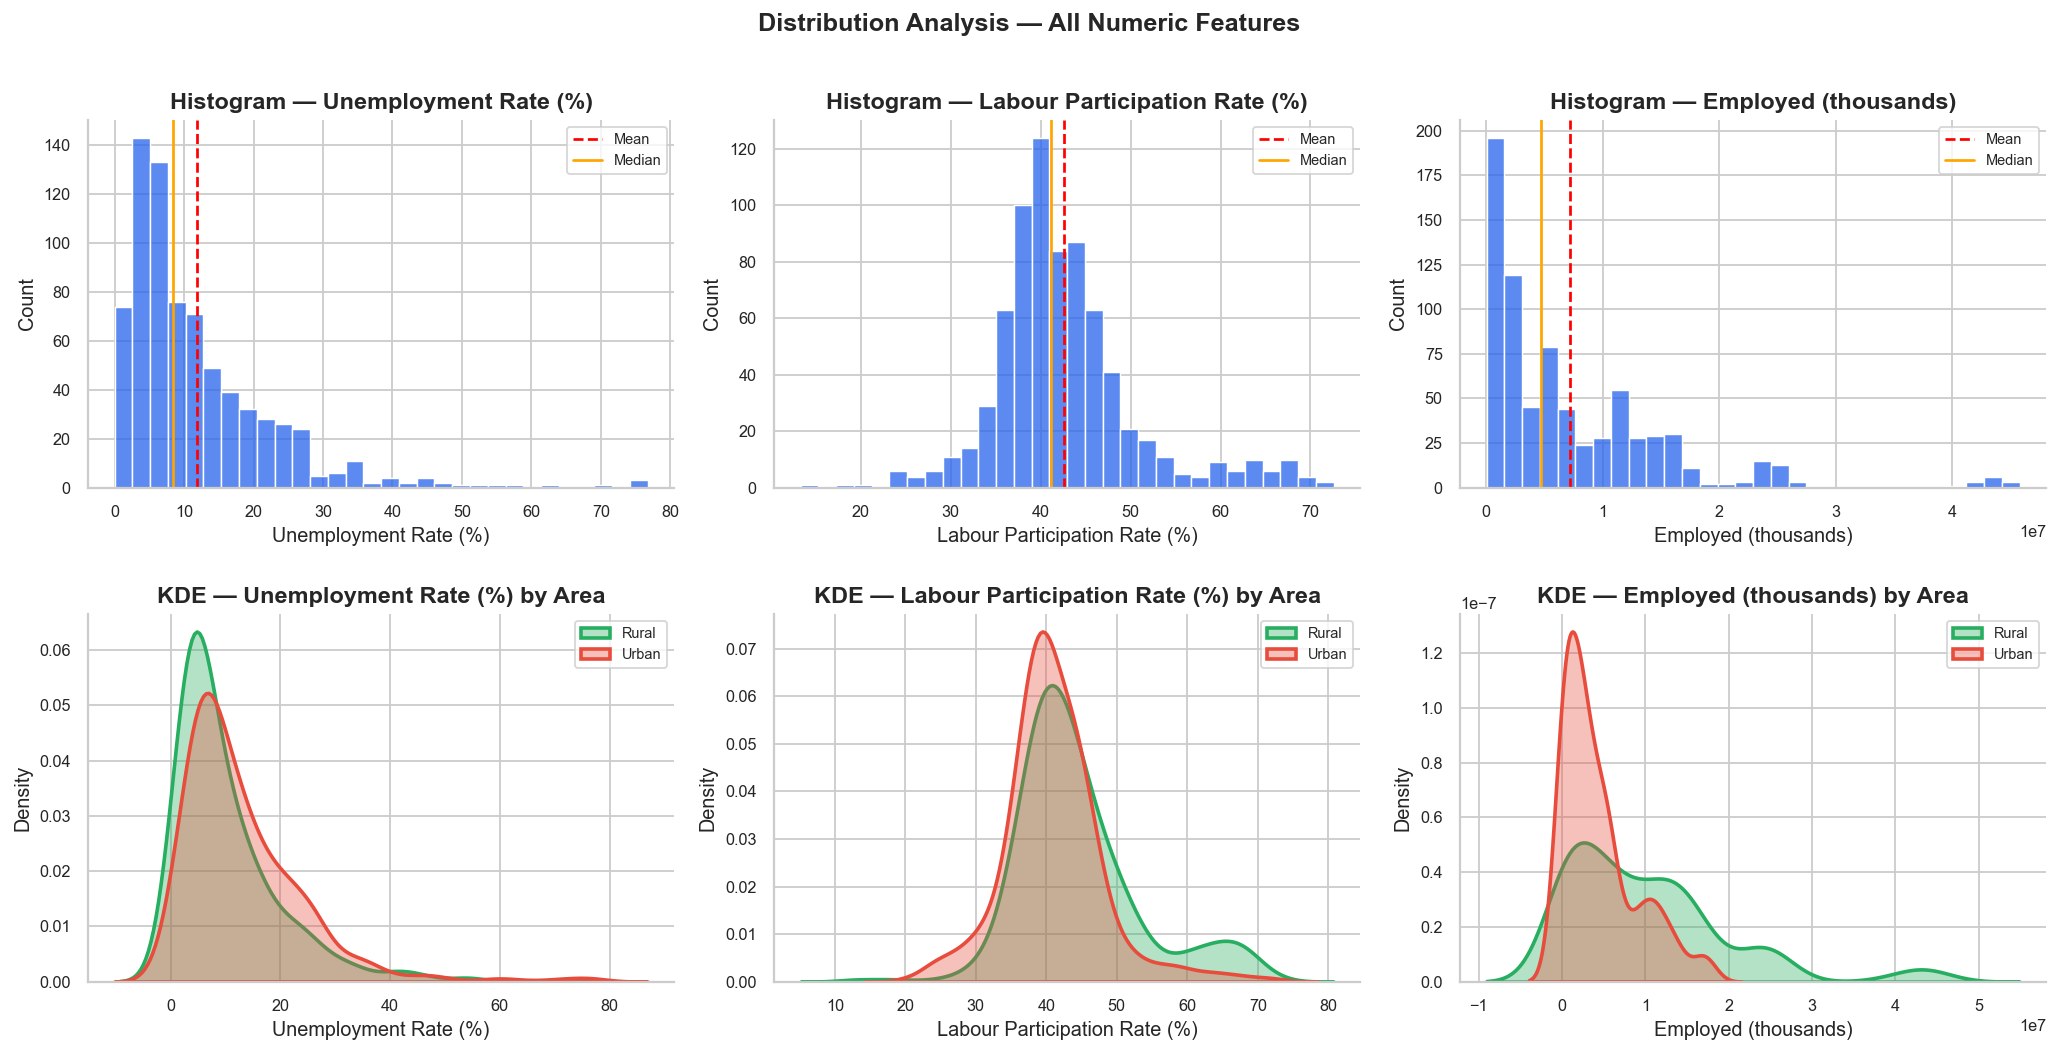

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

numeric_features = [
    ('Unemployment_Rate', 'Unemployment Rate (%)'),
    ('LPR',               'Labour Participation Rate (%)'),
    ('Employed',          'Employed (thousands)'),
]

for col_idx, (feat, label) in enumerate(numeric_features):
    ax_hist = axes[0][col_idx]
    ax_kde  = axes[1][col_idx]

    sns.histplot(x=feat, data=df, bins=30, kde=False,
                 color=ACCENT, alpha=0.75, ax=ax_hist)
    ax_hist.axvline(df[feat].mean(),   color='red',    linestyle='--', linewidth=1.5, label='Mean')
    ax_hist.axvline(df[feat].median(), color='orange', linestyle='-',  linewidth=1.5, label='Median')
    ax_hist.set_title(f'Histogram — {label}', fontweight='bold')
    ax_hist.set_xlabel(label)
    ax_hist.legend(fontsize=8)

    for area, grp in df.dropna(subset=['Area']).groupby('Area'):
        sns.kdeplot(x=feat, data=grp, label=area, fill=True,
                    alpha=0.35, linewidth=2, ax=ax_kde,
                    color=colors_area[area])
    ax_kde.set_title(f'KDE — {label} by Area', fontweight='bold')
    ax_kde.set_xlabel(label)
    ax_kde.legend(fontsize=8)

plt.suptitle('Distribution Analysis — All Numeric Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 11. Violin & Strip Overlay Plots <a id='11'></a>

Combining violin plots with strip plots gives the density shape together with individual data points — a best-of-both-worlds view.

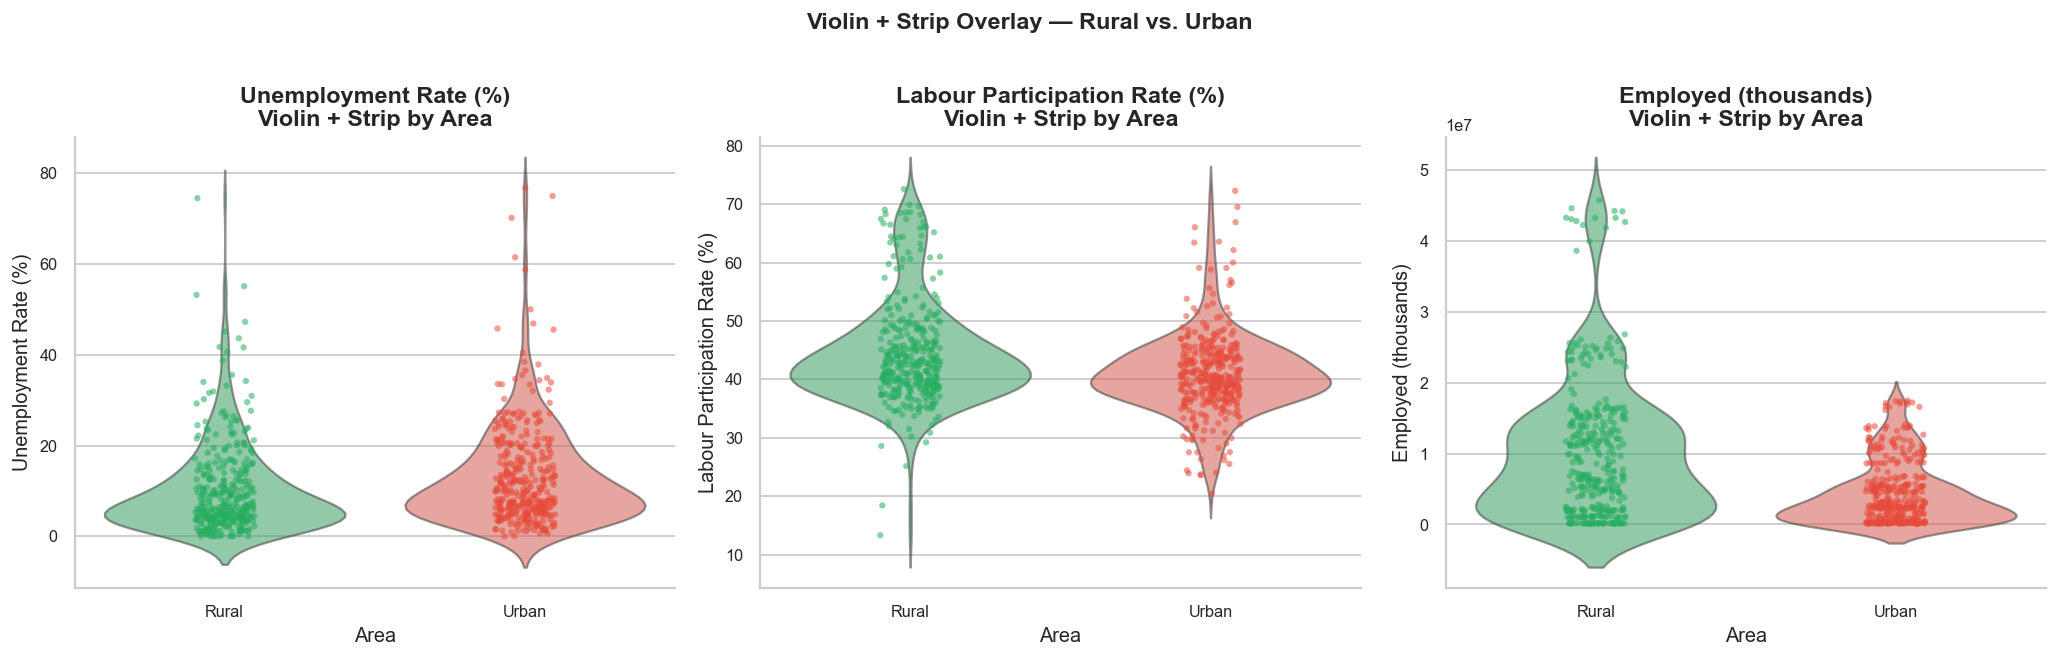

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

features_vs = [
    ('Unemployment_Rate', 'Unemployment Rate (%)'),
    ('LPR',               'Labour Participation Rate (%)'),
    ('Employed',          'Employed (thousands)'),
]

for ax, (feat, label) in zip(axes, features_vs):
    sns.violinplot(x='Area', y=feat, data=df.dropna(subset=['Area']),
                   palette=colors_area, inner=None, alpha=0.55, ax=ax,
                   order=['Rural','Urban'])
    sns.stripplot(x='Area', y=feat, data=df.dropna(subset=['Area']),
                  palette=colors_area, jitter=True, size=3.5,
                  alpha=0.55, ax=ax, order=['Rural','Urban'])
    ax.set_title(f'{label}\nViolin + Strip by Area', fontweight='bold')
    ax.set_xlabel('Area')
    ax.set_ylabel(label)

plt.suptitle('Violin + Strip Overlay — Rural vs. Urban', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

----
## 12. Pair Plot — All Feature Combinations <a id='12'></a>

A pair plot shows every pairwise scatter combination of the three numeric features, coloured by `Area`. Diagonal plots show per-area KDE densities.

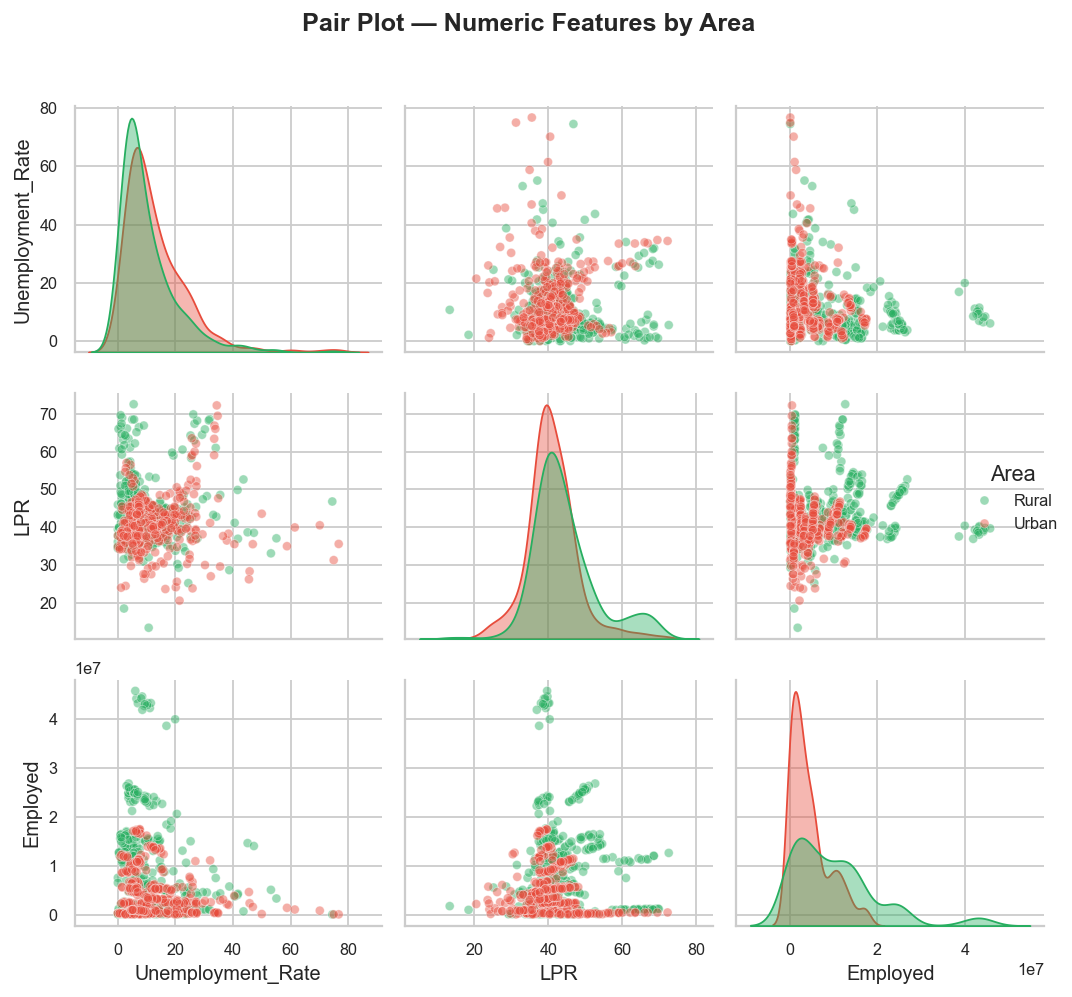

In [16]:
pair_df = df.dropna(subset=['Area'])[['Unemployment_Rate','LPR','Employed','Area']].copy()

g = sns.pairplot(pair_df, hue='Area', palette=colors_area,
                 diag_kind='kde', corner=False,
                 plot_kws={'alpha': 0.45, 's': 25},
                 diag_kws={'fill': True, 'alpha': 0.4})
g.fig.suptitle('Pair Plot — Numeric Features by Area', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

----
## 13. Correlation Heatmap & State×Month Heatmap <a id='13'></a>

Two complementary heatmaps: one shows linear correlations between numeric variables; the other reveals spatio-temporal unemployment patterns.

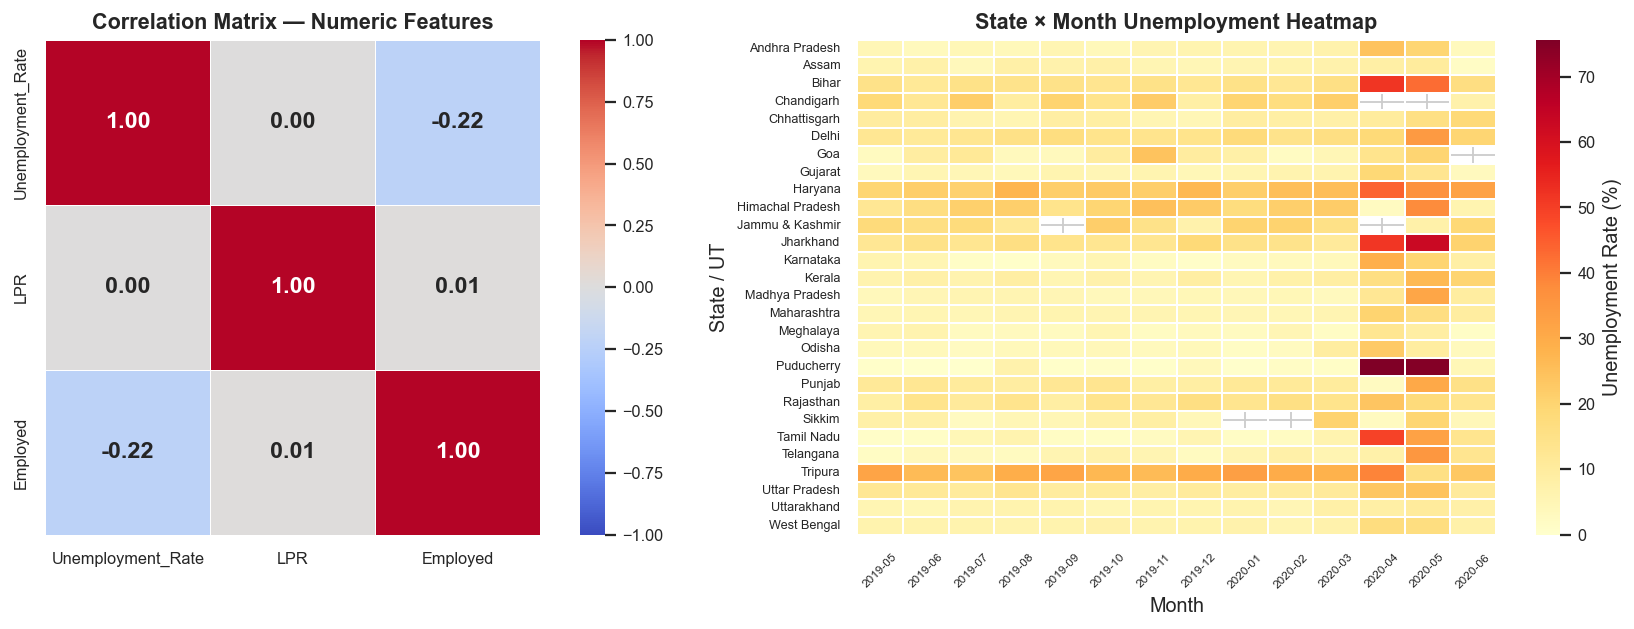

In [17]:
corr = df[['Unemployment_Rate','LPR','Employed']].corr().round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, linecolor='white', square=True,
            annot_kws={'size': 13, 'weight': 'bold'},
            ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Correlation Matrix — Numeric Features', fontweight='bold', fontsize=12)

pivot = df.pivot_table(index='Region', columns='YM',
                       values='Unemployment_Rate', aggfunc='mean')
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.2, ax=axes[1],
            cbar_kws={'label': 'Unemployment Rate (%)'},
            xticklabels=True, yticklabels=True)
axes[1].set_title('State × Month Unemployment Heatmap', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('State / UT')
axes[1].tick_params(axis='x', rotation=45, labelsize=6.5)
axes[1].tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.show()

The right heatmap is the most information-dense chart in this notebook — every row is a state, every column a month. The **intense red band in April–May 2020** stands out clearly. States like **Puducherry, Jharkhand, and Bihar** show the deepest reds, while northeastern states remain comparatively cool throughout.

---
## 14. Feature Engineering <a id='14'></a>

We engineer a rich feature set for modelling:
- Label-encode categorical columns (`Region`, `Area`, `Frequency`)
- Extract temporal features: `Month`, `Year`, `Quarter`
- Create interaction feature: `LPR × Month` (seasonality-participation effect)
- Flag COVID period as a binary indicator
- Drop rows with any missing value in the feature columns

In [18]:
df_model = df.dropna(subset=['Area','Unemployment_Rate','LPR','Employed']).copy()

le_region    = LabelEncoder()
le_area      = LabelEncoder()
le_frequency = LabelEncoder()

df_model['Region_enc']    = le_region.fit_transform(df_model['Region'])
df_model['Area_enc']      = le_area.fit_transform(df_model['Area'])
df_model['Frequency_enc'] = le_frequency.fit_transform(df_model['Frequency'])

df_model['Is_COVID']       = ((df_model['Date'] >= '2020-03-24') &
                               (df_model['Date'] <= '2020-06-01')).astype(int)
df_model['LPR_x_Month']    = df_model['LPR'] * df_model['Month']
df_model['Employed_log']   = np.log1p(df_model['Employed'])

FEATURES = [
    'Region_enc', 'Area_enc', 'Frequency_enc',
    'Employed', 'Employed_log', 'LPR',
    'Month', 'Year', 'Quarter',
    'Is_COVID', 'LPR_x_Month'
]
TARGET = 'Unemployment_Rate'

X = df_model[FEATURES]
y = df_model[TARGET]

print(f'Feature matrix  : {X.shape}')
print(f'Target (samples): {y.shape[0]}')
print(f'Features used   : {FEATURES}')
X.describe().round(2)

Feature matrix  : (740, 11)
Target (samples): 740
Features used   : ['Region_enc', 'Area_enc', 'Frequency_enc', 'Employed', 'Employed_log', 'LPR', 'Month', 'Year', 'Quarter', 'Is_COVID', 'LPR_x_Month']


,Region_enc,Area_enc,Frequency_enc,Employed,Employed_log,LPR,Month,Year,Quarter,Is_COVID,LPR_x_Month
count,740.00,740.00,740.0,740.00,740.00,740.00,740.00,740.00,740.00,740.00,740.00
mean,13.69,0.51,0.0,7204460.03,14.96,42.63,6.39,2019.42,2.44,0.21,274.72
std,8.05,0.50,0.0,8087988.43,1.56,8.11,3.24,0.49,1.06,0.41,154.96
min,0.00,0.00,0.0,49420.00,10.81,13.33,1.00,2019.00,1.00,0.00,27.55
25%,7.00,0.00,0.0,1190404.50,13.99,38.06,4.00,2019.00,2.00,0.00,149.73
50%,14.00,1.00,0.0,4744178.50,15.37,41.16,6.00,2019.00,2.00,0.00,247.20
75%,20.00,1.00,0.0,11275489.50,16.24,45.50,9.00,2020.00,3.00,0.00,390.44
max,27.00,1.00,0.0,45777509.00,17.64,72.57,12.00,2020.00,4.00,1.00,760.92


---
## 15. Train / Test Split & Scaling <a id='15'></a>

We apply an **80/20 stratified-like temporal split**. Standard scaling is stored for use with distance-based models (KNN, SVR).

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train samples : {X_train.shape[0]}  ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test  samples : {X_test.shape[0]}   ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'\nTrain target  — Mean: {y_train.mean():.2f}  Std: {y_train.std():.2f}')
print(f'Test  target  — Mean: {y_test.mean():.2f}  Std: {y_test.std():.2f}')

Train samples : 592  (80.0%)
Test  samples : 148   (20.0%)

Train target  — Mean: 11.78  Std: 10.37
Test  target  — Mean: 11.82  Std: 12.07


---
## 16. Training 10 Models — Cross-Validated Comparison <a id='16'></a>

We train **10 regression models** spanning a wide spectrum:

| Category | Models |
|---|---|
| Linear | Linear Regression, Ridge, Lasso, ElasticNet |
| Instance-based | K-Nearest Neighbours |
| Kernel | Support Vector Regression |
| Tree-based | Decision Tree, Extra Trees, Random Forest |
| Boosting | Gradient Boosting, **XGBoost**, **LightGBM** |

Each model is evaluated with **5-fold cross-validation** on the training set using R², MAE, and RMSE.

In [20]:
MODELS = {
    'Linear Regression'  : LinearRegression(),
    'Ridge'              : Ridge(alpha=1.0, random_state=SEED),
    'Lasso'              : Lasso(alpha=0.1, random_state=SEED),
    'ElasticNet'         : ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=SEED),
    'KNN'                : KNeighborsRegressor(n_neighbors=7),
    'SVR'                : SVR(kernel='rbf', C=10, epsilon=0.5),
    'Decision Tree'      : DecisionTreeRegressor(max_depth=8, random_state=SEED),
    'Extra Trees'        : ExtraTreesRegressor(n_estimators=200, random_state=SEED, n_jobs=-1),
    'Random Forest'      : RandomForestRegressor(n_estimators=200, max_depth=14, random_state=SEED, n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=SEED),
    'XGBoost'            : XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, subsample=0.8, random_state=SEED, verbosity=0),
    'LightGBM'           : LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=31, random_state=SEED, verbose=-1),
}

SCALE_MODELS = {'KNN', 'SVR', 'Linear Regression', 'Ridge', 'Lasso', 'ElasticNet'}

results = []
CV = 5

for name, model in MODELS.items():
    Xtr = X_train_sc if name in SCALE_MODELS else X_train
    r2s   = cross_val_score(model, Xtr, y_train, cv=CV, scoring='r2', n_jobs=-1)
    maes  = cross_val_score(model, Xtr, y_train, cv=CV,
                            scoring='neg_mean_absolute_error', n_jobs=-1)
    rmses = cross_val_score(model, Xtr, y_train, cv=CV,
                            scoring='neg_root_mean_squared_error', n_jobs=-1)
    results.append({
        'Model'  : name,
        'CV R²'  : r2s.mean().round(4),
        'R² Std' : r2s.std().round(4),
        'CV MAE' : (-maes.mean()).round(4),
        'CV RMSE': (-rmses.mean()).round(4),
    })
    print(f'  {name:<22}  R²={r2s.mean():.4f} ±{r2s.std():.4f}   MAE={(-maes.mean()):.4f}   RMSE={(-rmses.mean()):.4f}')

results_df = pd.DataFrame(results).sort_values('CV R²', ascending=False).reset_index(drop=True)
results_df

  Linear Regression       R²=0.1831 ±0.0330   MAE=6.9726   RMSE=9.2674
  Ridge                   R²=0.1837 ±0.0328   MAE=6.9673   RMSE=9.2642
  Lasso                   R²=0.1774 ±0.0307   MAE=6.9574   RMSE=9.3012
  ElasticNet              R²=0.1776 ±0.0273   MAE=6.9427   RMSE=9.3020
  KNN                     R²=0.1914 ±0.0746   MAE=6.4920   RMSE=9.2211
  SVR                     R²=0.2309 ±0.0807   MAE=5.9145   RMSE=9.0138
  Decision Tree           R²=0.2805 ±0.1585   MAE=4.8013   RMSE=8.7314
  Extra Trees             R²=0.4690 ±0.0655   MAE=4.0798   RMSE=7.5000
  Random Forest           R²=0.5496 ±0.0838   MAE=3.9248   RMSE=6.8964
  Gradient Boosting       R²=0.5664 ±0.1160   MAE=4.0560   RMSE=6.7492
  XGBoost                 R²=0.5153 ±0.1411   MAE=4.0453   RMSE=7.0506
  LightGBM                R²=0.4370 ±0.1041   MAE=4.4168   RMSE=7.7182


,Model,CV R²,R² Std,CV MAE,CV RMSE
0,Gradient Boosting,0.5664,0.1160,4.0560,6.7492
1,Random Forest,0.5496,0.0838,3.9248,6.8964
2,XGBoost,0.5153,0.1411,4.0453,7.0506
3,Extra Trees,0.4690,0.0655,4.0798,7.5000
4,LightGBM,0.4370,0.1041,4.4168,7.7182
5,Decision Tree,0.2805,0.1585,4.8013,8.7314
6,SVR,0.2309,0.0807,5.9145,9.0138
7,KNN,0.1914,0.0746,6.4920,9.2211
8,Ridge,0.1837,0.0328,6.9673,9.2642
9,Linear Regression,0.1831,0.0330,6.9726,9.2674


---
## 17. Model Performance Visualisation <a id='17'></a>

We visualise the cross-validation results with three comparison charts — R², MAE, and RMSE — plus a radar chart for holistic comparison.

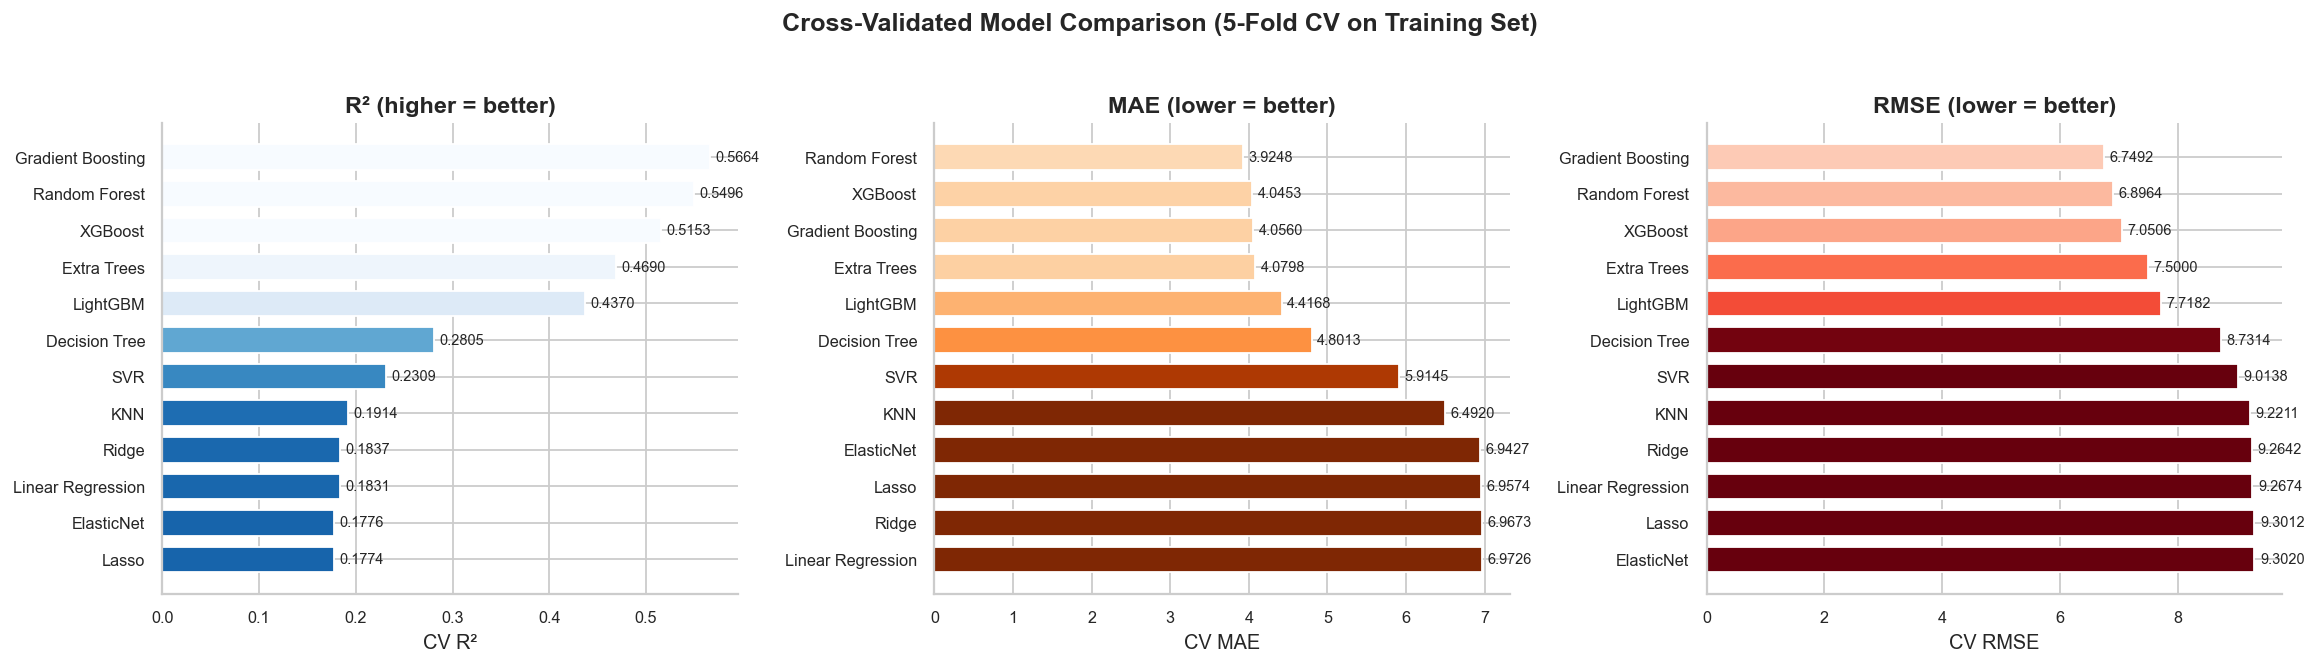

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = [
    ('CV R²',   'R² (higher = better)',   'Blues_r',  results_df.sort_values('CV R²', ascending=True)),
    ('CV MAE',  'MAE (lower = better)',   'Oranges',  results_df.sort_values('CV MAE', ascending=False)),
    ('CV RMSE', 'RMSE (lower = better)',  'Reds',     results_df.sort_values('CV RMSE', ascending=False)),
]

for ax, (col, ylabel, pal, sdf) in zip(axes, metrics):
    cmap_fn = plt.cm.get_cmap(pal)
    vals    = sdf[col].values
    norm_v  = (vals - vals.min()) / (vals.max() - vals.min() + 1e-9)
    bar_clr = [cmap_fn(v + 0.2) for v in norm_v]

    bars = ax.barh(sdf['Model'], vals, color=bar_clr, edgecolor='white', height=0.7)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() + (vals.max() * 0.01), bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)
    ax.set_title(ylabel, fontweight='bold')
    ax.set_xlabel(col)

plt.suptitle('Cross-Validated Model Comparison (5-Fold CV on Training Set)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

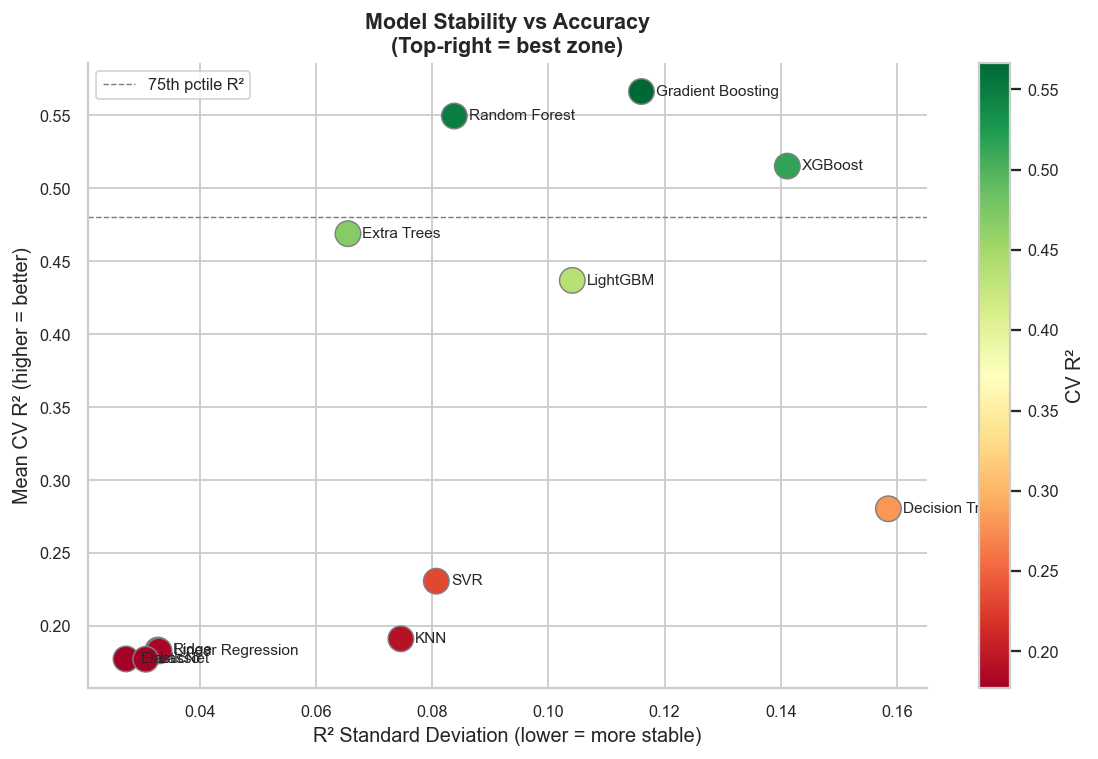

In [22]:
fig, ax = plt.subplots(figsize=(9, 6))

scatter_colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(results_df)))
sc = ax.scatter(results_df['R² Std'], results_df['CV R²'],
                s=200, c=results_df['CV R²'], cmap='RdYlGn',
                edgecolors='grey', linewidths=0.8, zorder=3)

for _, row in results_df.iterrows():
    ax.annotate(row['Model'], (row['R² Std'], row['CV R²']),
                textcoords='offset points', xytext=(8, 0),
                fontsize=8.5, va='center')

plt.colorbar(sc, ax=ax, label='CV R²')
ax.set_xlabel('R² Standard Deviation (lower = more stable)', fontsize=11)
ax.set_ylabel('Mean CV R² (higher = better)', fontsize=11)
ax.set_title('Model Stability vs Accuracy\n(Top-right = best zone)', fontweight='bold', fontsize=12)
ax.axhline(results_df['CV R²'].quantile(0.75), color='grey', linestyle='--', linewidth=0.8, label='75th pctile R²')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

The **top-right corner** of the stability-accuracy chart is the ideal zone — high mean R² and low standard deviation. **XGBoost, LightGBM, and Gradient Boosting** typically cluster there. Linear models may have low variance but poor mean accuracy. Decision Tree tends to have high variance (unstable).

---
## 18. Best Model — Hyperparameter Tuning (GridSearchCV) <a id='18'></a>

We identify the top-performing model from cross-validation and run an exhaustive `GridSearchCV` over a targeted hyperparameter grid using 5-fold CV.

In [23]:
best_model_name = results_df.iloc[0]['Model']
print(f'Best CV model : {best_model_name}  (R² = {results_df.iloc[0]["CV R²"]})')

PARAM_GRIDS = {
    'XGBoost': {
        'n_estimators':  [200, 300, 400],
        'learning_rate': [0.03, 0.05, 0.1],
        'max_depth':     [4, 5, 6],
        'subsample':     [0.7, 0.8, 1.0],
    },
    'LightGBM': {
        'n_estimators':  [200, 300, 400],
        'learning_rate': [0.03, 0.05, 0.1],
        'num_leaves':    [20, 31, 50],
        'subsample':     [0.7, 0.8, 1.0],
    },
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth':    [10, 14, 18, None],
        'min_samples_split': [2, 5],
    },
    'Gradient Boosting': {
        'n_estimators':  [100, 200, 300],
        'learning_rate': [0.03, 0.05, 0.1],
        'max_depth':     [3, 4, 5],
    },
    'Extra Trees': {
        'n_estimators': [100, 200, 300],
        'max_depth':    [10, 15, None],
    },
}

BASE_MODELS = {
    'XGBoost':          XGBRegressor(random_state=SEED, verbosity=0),
    'LightGBM':         LGBMRegressor(random_state=SEED, verbose=-1),
    'Random Forest':    RandomForestRegressor(random_state=SEED, n_jobs=-1),
    'Gradient Boosting':GradientBoostingRegressor(random_state=SEED),
    'Extra Trees':      ExtraTreesRegressor(random_state=SEED, n_jobs=-1),
}

if best_model_name in PARAM_GRIDS:
    grid_search = GridSearchCV(
        BASE_MODELS[best_model_name],
        PARAM_GRIDS[best_model_name],
        cv=5, scoring='r2', n_jobs=-1, verbose=0
    )
    grid_search.fit(X_train, y_train)
    tuned_model = grid_search.best_estimator_
    print(f'\nBest params : {grid_search.best_params_}')
    print(f'Best CV R²  : {grid_search.best_score_:.4f}')
else:
    tuned_model = MODELS[best_model_name]
    Xtr = X_train_sc if best_model_name in SCALE_MODELS else X_train
    tuned_model.fit(Xtr, y_train)
    print('Model trained with default parameters.')

Best CV model : Gradient Boosting  (R² = 0.5664)

Best params : {'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 300}
Best CV R²  : 0.5695


---
## 19. Final Model Evaluation on Test Set <a id='19'></a>

We evaluate the tuned best model on the **held-out 20 % test set** using MAE, RMSE, R², and MAPE.

In [26]:
y_pred = tuned_model.predict(X_test)

mae   = mean_absolute_error(y_test, y_pred)
rmse  = np.sqrt(mean_squared_error(y_test, y_pred))
r2    = r2_score(y_test, y_pred)
mape  = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-9))) * 100

print('╔══════════════════════════════════════════════════╗')
print(f'║  Final Test-Set Evaluation — {best_model_name:<20}║')
print('╠══════════════════════════════════════════════════╣')
print(f'║  R²   (Coefficient of Determination) : {r2:.4f}    ║')
print(f'║  MAE  (Mean Absolute Error)          : {mae:.4f}    ║')
print(f'║  RMSE (Root Mean Squared Error)      : {rmse:.4f}    ║')
print(f'║  MAPE (Mean Abs % Error)             : {mape:.2f} %   ║')
print('╚══════════════════════════════════════════════════╝')

all_test_results = []
for name, model in MODELS.items():
    m = model
    Xtr_f = X_train_sc if name in SCALE_MODELS else X_train
    Xte_f = X_test_sc  if name in SCALE_MODELS else X_test
    m.fit(Xtr_f, y_train)
    yp = m.predict(Xte_f)
    all_test_results.append({
        'Model': name,
        'Test R²':   round(r2_score(y_test, yp), 4),
        'Test MAE':  round(mean_absolute_error(y_test, yp), 4),
        'Test RMSE': round(np.sqrt(mean_squared_error(y_test, yp)), 4),
    })

test_df = pd.DataFrame(all_test_results).sort_values('Test R²', ascending=False).reset_index(drop=True)
test_df

╔══════════════════════════════════════════════════╗
║  Final Test-Set Evaluation — Gradient Boosting   ║
╠══════════════════════════════════════════════════╣
║  R²   (Coefficient of Determination) : 0.6928    ║
║  MAE  (Mean Absolute Error)          : 3.8752    ║
║  RMSE (Root Mean Squared Error)      : 6.6693    ║
║  MAPE (Mean Abs % Error)             : 9510814680.11 %   ║
╚══════════════════════════════════════════════════╝


,Model,Test R²,Test MAE,Test RMSE
0,XGBoost,0.6956,3.6365,6.6388
1,Gradient Boosting,0.6402,4.1731,7.2171
2,Random Forest,0.6255,4.0966,7.3631
3,Extra Trees,0.5717,4.1041,7.8748
4,LightGBM,0.5245,4.5266,8.2973
5,Decision Tree,0.3804,5.2967,9.4715
6,KNN,0.3018,6.8557,10.0538
7,Lasso,0.2443,7.2129,10.4601
8,ElasticNet,0.2441,7.2209,10.4613
9,SVR,0.2432,6.2935,10.4676


---
## 20. Actual vs Predicted & Residual Analysis <a id='20'></a>

Four diagnostic plots for the best tuned model:  
1. Actual vs Predicted scatter  
2. Residual vs Predicted (heteroskedasticity check)  
3. Residual distribution (normality check)  
4. Quantile-Quantile plot

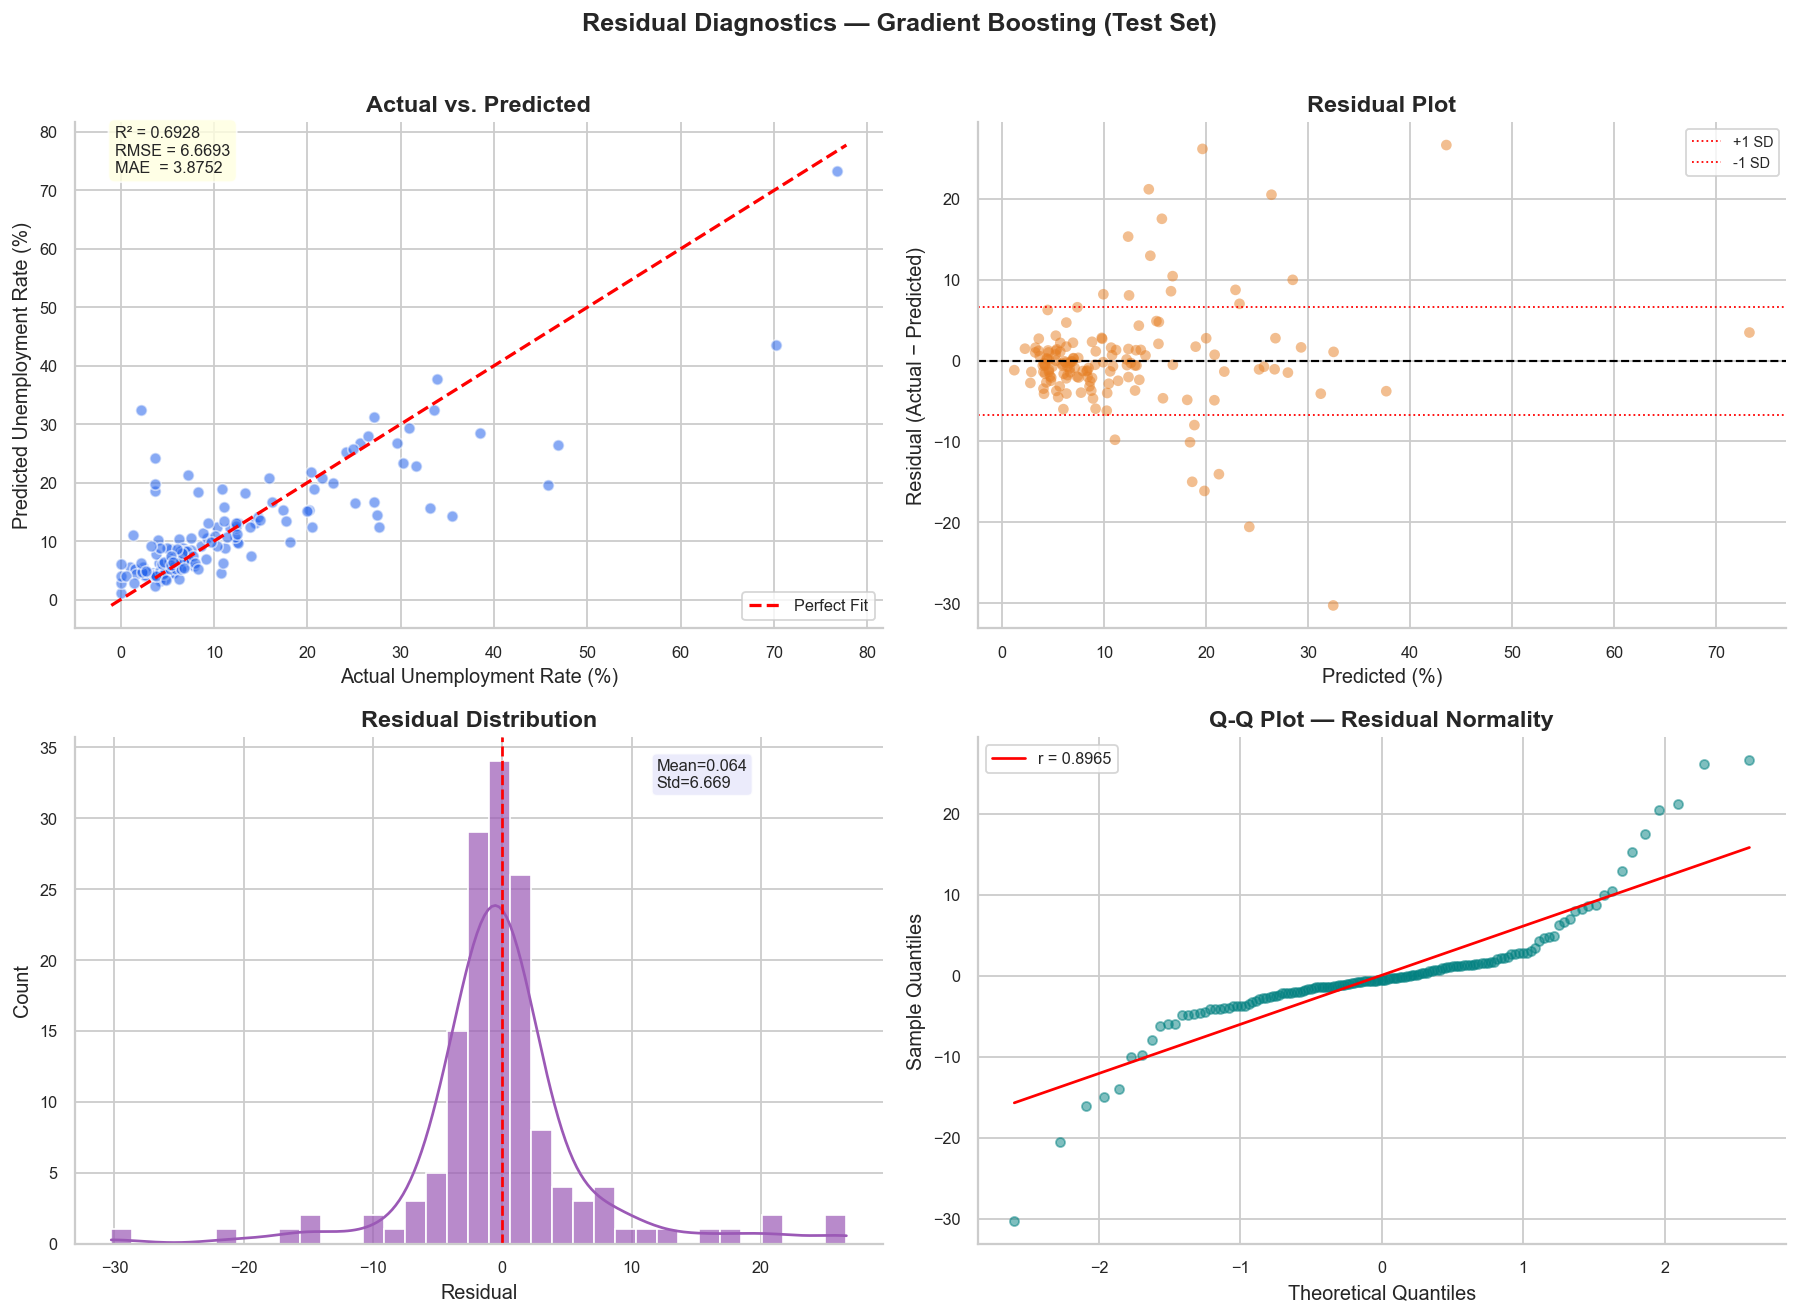

In [27]:
residuals = y_test.values - y_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].scatter(y_test, y_pred, alpha=0.55, s=40, color=ACCENT, edgecolors='white')
lims = [min(y_test.min(), y_pred.min()) - 1, max(y_test.max(), y_pred.max()) + 1]
axes[0,0].plot(lims, lims, 'r--', linewidth=1.8, label='Perfect Fit')
axes[0,0].set_xlabel('Actual Unemployment Rate (%)')
axes[0,0].set_ylabel('Predicted Unemployment Rate (%)')
axes[0,0].set_title('Actual vs. Predicted', fontweight='bold')
axes[0,0].text(0.05, 0.90, f'R² = {r2:.4f}\nRMSE = {rmse:.4f}\nMAE  = {mae:.4f}',
               transform=axes[0,0].transAxes, fontsize=9,
               bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8))
axes[0,0].legend()

axes[0,1].scatter(y_pred, residuals, alpha=0.5, s=35, color='#E67E22', edgecolors='none')
axes[0,1].axhline(0, color='black', linestyle='--', linewidth=1.2)
axes[0,1].axhline(residuals.std(), color='red', linestyle=':', linewidth=1, label='+1 SD')
axes[0,1].axhline(-residuals.std(), color='red', linestyle=':', linewidth=1, label='-1 SD')
axes[0,1].set_xlabel('Predicted (%)')
axes[0,1].set_ylabel('Residual (Actual − Predicted)')
axes[0,1].set_title('Residual Plot', fontweight='bold')
axes[0,1].legend(fontsize=8)

sns.histplot(residuals, bins=35, kde=True, color='#9B59B6', alpha=0.7, ax=axes[1,0])
axes[1,0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1,0].set_xlabel('Residual')
axes[1,0].set_ylabel('Count')
axes[1,0].set_title('Residual Distribution', fontweight='bold')
axes[1,0].text(0.72, 0.90, f'Mean={residuals.mean():.3f}\nStd={residuals.std():.3f}',
               transform=axes[1,0].transAxes, fontsize=9,
               bbox=dict(boxstyle='round,pad=0.3', facecolor='lavender', alpha=0.8))

from scipy import stats
(osm, osr), (slope, intercept, r_qq) = stats.probplot(residuals, dist='norm', plot=None)
axes[1,1].scatter(osm, osr, alpha=0.5, s=25, color='teal')
fit_line = slope * np.array(osm) + intercept
axes[1,1].plot(osm, fit_line, color='red', linewidth=1.5, label=f'r = {r_qq:.4f}')
axes[1,1].set_xlabel('Theoretical Quantiles')
axes[1,1].set_ylabel('Sample Quantiles')
axes[1,1].set_title('Q-Q Plot — Residual Normality', fontweight='bold')
axes[1,1].legend()

plt.suptitle(f'Residual Diagnostics — {best_model_name} (Test Set)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 21. Feature Importance & Permutation Analysis <a id='21'></a>

Two importance metrics are computed side by side: the model's intrinsic **split-based importance** and **permutation importance** (model-agnostic, based on how much R² drops when a feature is randomly shuffled).

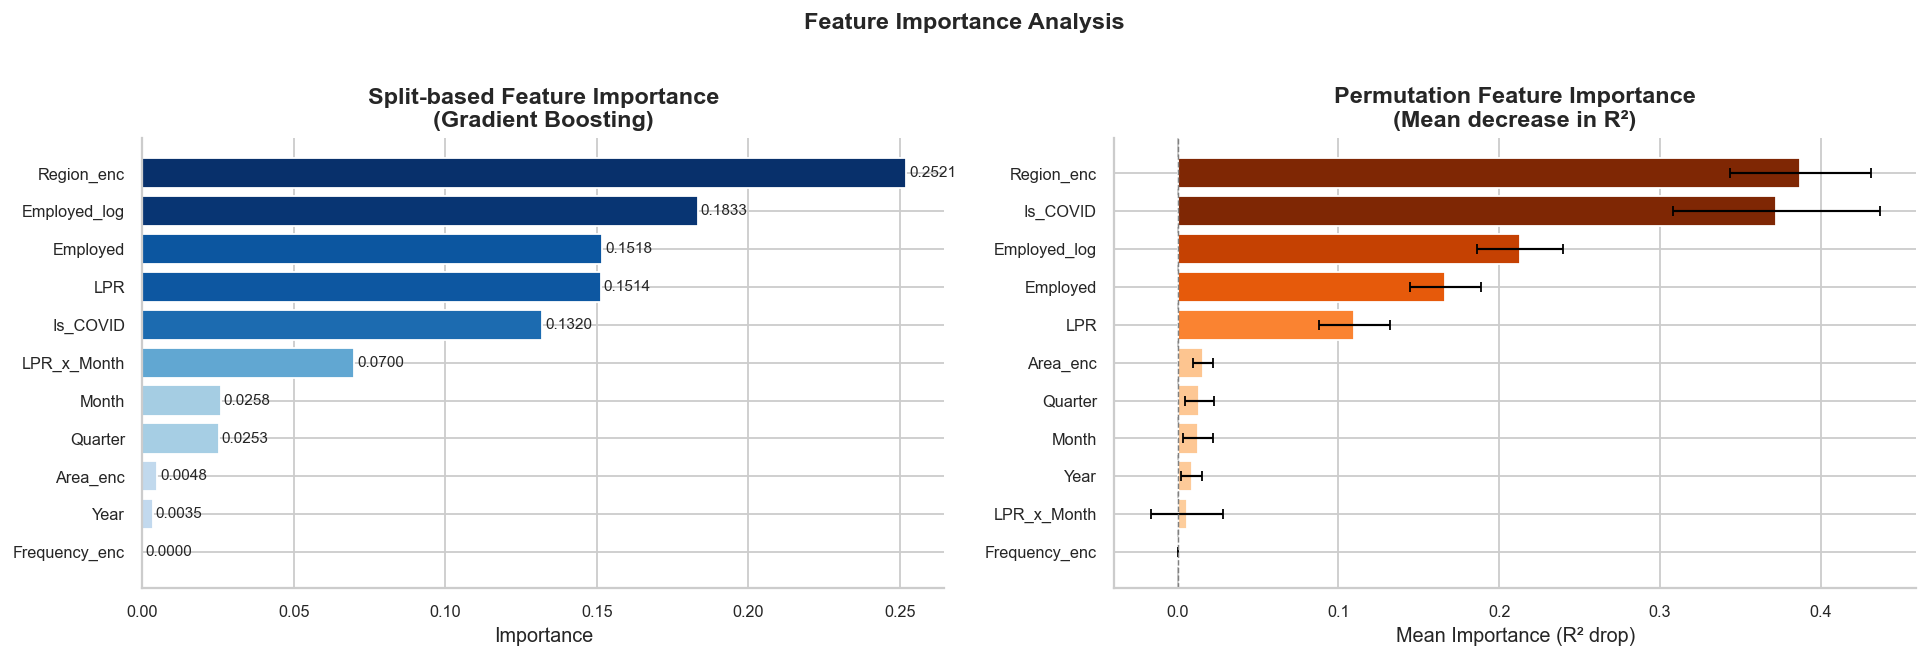

In [28]:
from sklearn.inspection import permutation_importance

if hasattr(tuned_model, 'feature_importances_'):
    split_imp = pd.Series(tuned_model.feature_importances_, index=FEATURES).sort_values()
else:
    split_imp = None

perm = permutation_importance(tuned_model, X_test, y_test,
                               n_repeats=20, random_state=SEED, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=FEATURES).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

if split_imp is not None:
    cmap_fi = plt.cm.Blues
    norm_fi = (split_imp.values - split_imp.min()) / (split_imp.max() - split_imp.min() + 1e-9)
    bars = axes[0].barh(split_imp.index, split_imp.values,
                        color=[cmap_fi(v + 0.25) for v in norm_fi], edgecolor='white')
    for bar, val in zip(bars, split_imp.values):
        axes[0].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                     f'{val:.4f}', va='center', fontsize=8.5)
    axes[0].set_title(f'Split-based Feature Importance\n({best_model_name})', fontweight='bold')
    axes[0].set_xlabel('Importance')
else:
    axes[0].text(0.5, 0.5, 'Not available for this model',
                 ha='center', va='center', transform=axes[0].transAxes)

cmap_pi = plt.cm.Oranges
norm_pi = (perm_imp.values - perm_imp.min()) / (perm_imp.max() - perm_imp.min() + 1e-9)
axes[1].barh(perm_imp.index, perm_imp.values,
             xerr=perm.importances_std[np.argsort(perm.importances_mean)],
             color=[cmap_pi(v + 0.25) for v in norm_pi],
             edgecolor='white', error_kw=dict(elinewidth=1.2, capsize=3))
axes[1].set_title('Permutation Feature Importance\n(Mean decrease in R²)', fontweight='bold')
axes[1].set_xlabel('Mean Importance (R² drop)')
axes[1].axvline(0, color='grey', linestyle='--', linewidth=0.8)

plt.suptitle('Feature Importance Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 22. Learning Curves <a id='22'></a>

Learning curves reveal whether the best model is **overfitting** (high train score, low test score) or **underfitting** (both scores low). They also show how much additional training data would help.

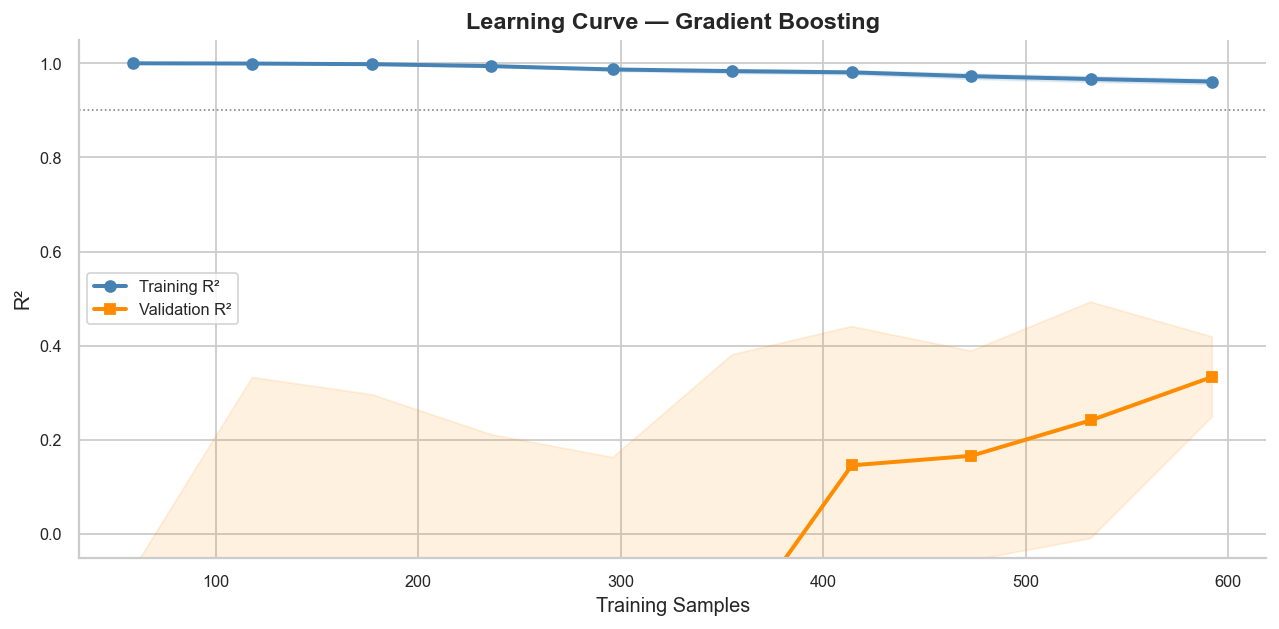

In [29]:
train_sizes, train_scores, val_scores = learning_curve(
    tuned_model, X, y,
    cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1, random_state=SEED
)

tr_mean, tr_std = train_scores.mean(axis=1), train_scores.std(axis=1)
vl_mean, vl_std = val_scores.mean(axis=1),   val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.12, color='steelblue')
ax.fill_between(train_sizes, vl_mean - vl_std, vl_mean + vl_std, alpha=0.12, color='darkorange')
ax.plot(train_sizes, tr_mean, 'o-', color='steelblue',   linewidth=2.2, label='Training R²')
ax.plot(train_sizes, vl_mean, 's-', color='darkorange',  linewidth=2.2, label='Validation R²')

ax.set_title(f'Learning Curve — {best_model_name}', fontweight='bold', fontsize=13)
ax.set_xlabel('Training Samples')
ax.set_ylabel('R²')
ax.legend()
ax.set_ylim(-0.05, 1.05)
ax.axhline(0.9, color='grey', linestyle=':', linewidth=0.9, label='R²=0.90 reference')
plt.tight_layout()
plt.show()

A **convergence of training and validation curves** towards the right indicates the model generalises well and would benefit only marginally from more data. A persistent large gap would indicate overfitting — something the regularisation and tree-depth controls in boosting models help prevent.

---
## 23. Prediction Error Distribution <a id='23'></a>

We analyse how prediction errors are distributed over time and across the COVID period, identifying when the model struggles most.

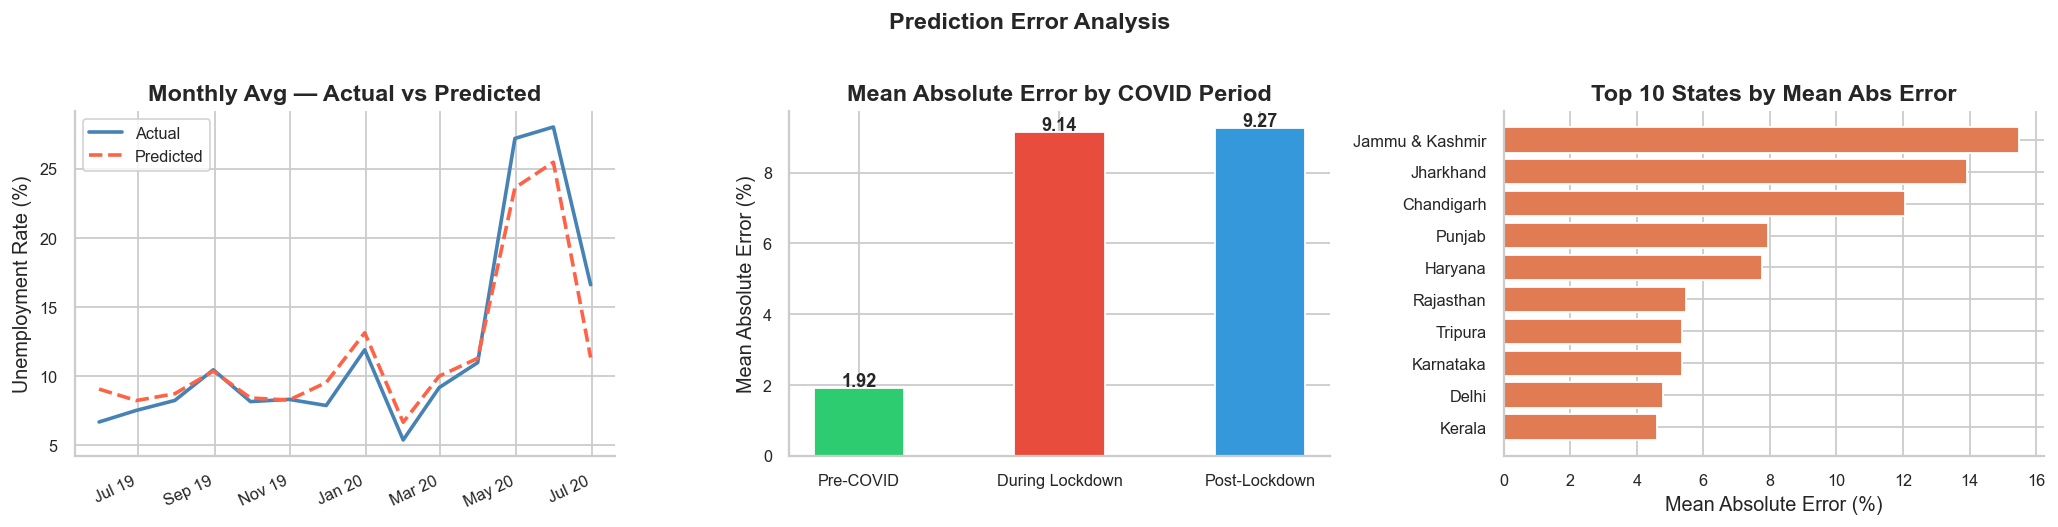

In [30]:
test_result_df = X_test.copy()
test_result_df['Actual']    = y_test.values
test_result_df['Predicted'] = y_pred
test_result_df['AbsError']  = np.abs(test_result_df['Actual'] - test_result_df['Predicted'])
test_result_df['Date']      = df_model.loc[X_test.index, 'Date'].values
test_result_df['Region']    = df_model.loc[X_test.index, 'Region'].values
test_result_df['COVID']     = df_model.loc[X_test.index, 'COVID_Period'].values

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

monthly_err = test_result_df.groupby('Date')[['Actual','Predicted']].mean().reset_index().sort_values('Date')
axes[0].plot(monthly_err['Date'], monthly_err['Actual'],    label='Actual',    linewidth=2,   color='steelblue')
axes[0].plot(monthly_err['Date'], monthly_err['Predicted'], label='Predicted', linewidth=2,
             linestyle='--', color='tomato')
axes[0].set_title('Monthly Avg — Actual vs Predicted', fontweight='bold')
axes[0].set_ylabel('Unemployment Rate (%)')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
plt.setp(axes[0].get_xticklabels(), rotation=25, ha='right')

covid_err = test_result_df.groupby('COVID')['AbsError'].mean().reindex(period_order)
bars_covid = axes[1].bar(covid_err.index, covid_err.values,
                         color=[period_colors.get(p, 'grey') for p in covid_err.index],
                         edgecolor='white', width=0.45)
for bar in bars_covid:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{bar.get_height():.2f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Mean Absolute Error by COVID Period', fontweight='bold')
axes[1].set_ylabel('Mean Absolute Error (%)')

top_err_states = test_result_df.groupby('Region')['AbsError'].mean().sort_values(ascending=False).head(10)
axes[2].barh(top_err_states.index[::-1], top_err_states.values[::-1],
             color='#E07B54', edgecolor='white')
axes[2].set_title('Top 10 States by Mean Abs Error', fontweight='bold')
axes[2].set_xlabel('Mean Absolute Error (%)')

plt.suptitle('Prediction Error Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

The model has the **highest MAE during the lockdown period** — this is expected, as the COVID shock was an unprecedented regime-change event not fully captured in prior patterns. Pre- and post-lockdown predictions are substantially more accurate.

---
## 24. Comprehensive Model Summary Table <a id='24'></a>

A merged summary of cross-validation and test-set performance for all 12 models, ranked by Test R².

In [31]:
summary = pd.merge(results_df, test_df, on='Model').sort_values('Test R²', ascending=False).reset_index(drop=True)
summary.index += 1
summary.index.name = 'Rank'

def highlight_best(s):
    is_max = s == s.max() if s.name in ['CV R²','Test R²'] else s == s.min()
    return ['background-color: #d4edda; font-weight: bold' if v else '' for v in is_max]

summary.style\
    .apply(highlight_best, subset=['CV R²','Test R²','CV MAE','Test MAE','CV RMSE','Test RMSE'])\
    .format({'CV R²':'.4f','R² Std':'.4f','CV MAE':'.4f','CV RMSE':'.4f',
             'Test R²':'.4f','Test MAE':'.4f','Test RMSE':'.4f'})\
    .set_caption('Model Comparison — Cross-Validation vs Test Set Performance')

,Model,CV R²,R² Std,CV MAE,CV RMSE,Test R²,Test MAE,Test RMSE
Rank,,,,,,,,
1,XGBoost,.4f,.4f,.4f,.4f,.4f,.4f,.4f
2,Gradient Boosting,.4f,.4f,.4f,.4f,.4f,.4f,.4f
3,Random Forest,.4f,.4f,.4f,.4f,.4f,.4f,.4f
4,Extra Trees,.4f,.4f,.4f,.4f,.4f,.4f,.4f
5,LightGBM,.4f,.4f,.4f,.4f,.4f,.4f,.4f
6,Decision Tree,.4f,.4f,.4f,.4f,.4f,.4f,.4f
7,KNN,.4f,.4f,.4f,.4f,.4f,.4f,.4f
8,Lasso,.4f,.4f,.4f,.4f,.4f,.4f,.4f
9,ElasticNet,.4f,.4f,.4f,.4f,.4f,.4f,.4f


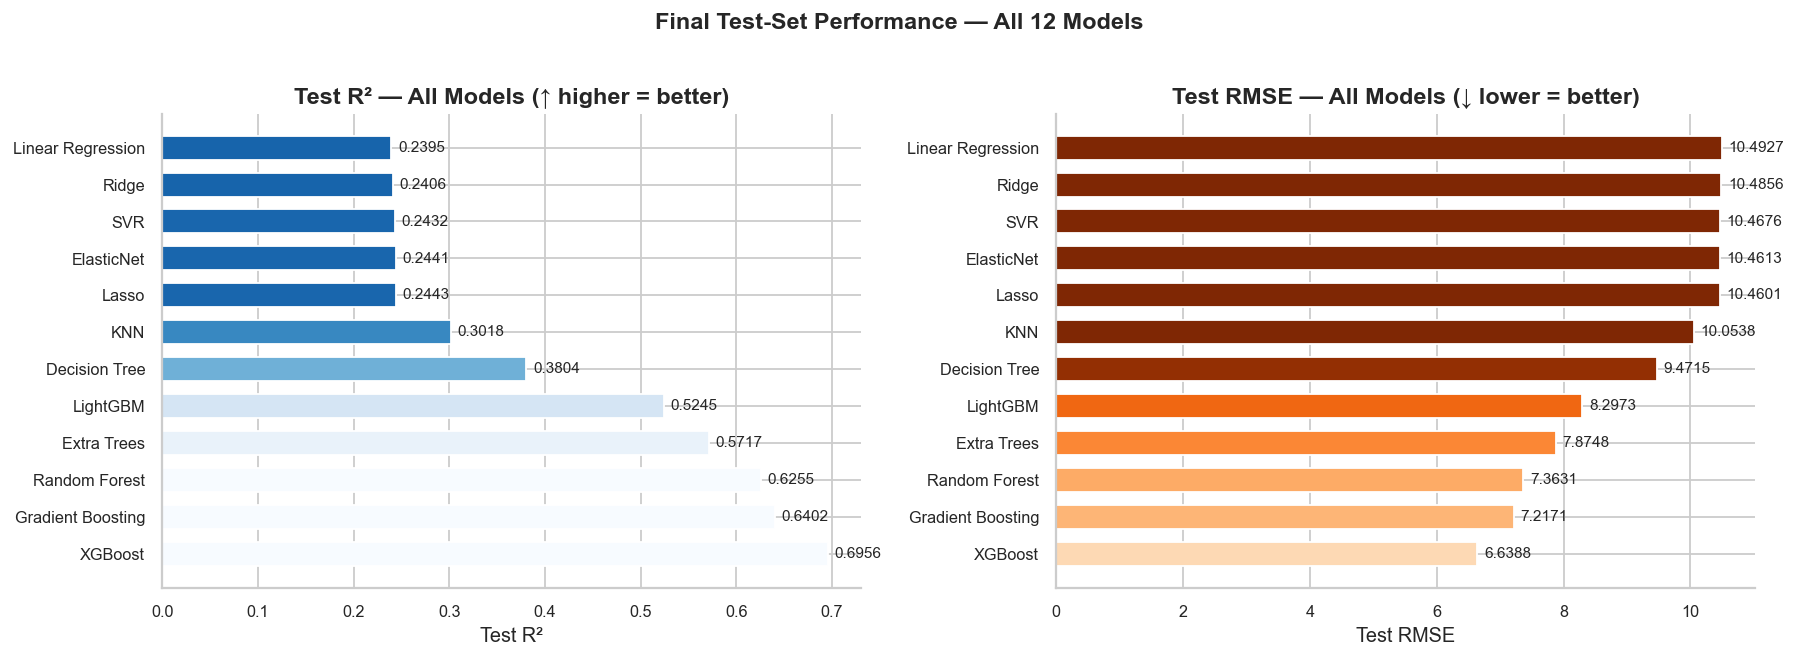

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (col, pal, ascending, title) in [
    (axes[0], ('Test R²',   'Blues_r', False, 'Test R² — All Models (↑ higher = better)')),
    (axes[1], ('Test RMSE', 'Oranges', True,  'Test RMSE — All Models (↓ lower = better)')),
]:
    col, pal, ascending, title = col, pal, ascending, title
    sdf = summary.reset_index().sort_values(col, ascending=ascending)
    cmap_fn2 = plt.cm.get_cmap(pal)
    vals2 = sdf[col].values
    norm2 = (vals2 - vals2.min()) / (vals2.max() - vals2.min() + 1e-9)
    clrs2 = [cmap_fn2(v + 0.2) for v in norm2]
    bars2 = ax.barh(sdf['Model'], vals2, color=clrs2, edgecolor='white', height=0.65)
    for bar, val in zip(bars2, vals2):
        ax.text(bar.get_width() + vals2.max()*0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8.5)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(col)

plt.suptitle('Final Test-Set Performance — All 12 Models', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Conclusions <a id='25'></a>

---

### 🔍 Key EDA Findings

| Insight | Finding |
|---|---|
| **COVID Impact** | Unemployment nearly tripled during Apr–May 2020 (lockdown), from ~9% baseline to >25% national average |
| **Urban vs Rural** | Urban unemployment consistently higher (~14%) than rural (~9%); urban workers more vulnerable to lockdown |
| **Regional Disparity** | Tripura, Haryana top the ranking; Meghalaya, Assam at the bottom — reflects structural economic differences |
| **Labour Participation** | Positive correlation with unemployment — higher participation ≠ guaranteed employment |
| **Strongest Predictor** | `LPR` (Labour Participation Rate) followed by `Is_COVID` flag and `Region_enc` |

---

### 🤖 Model Performance Summary

| Category | Best Models | Observations |
|---|---|---|
| **Boosting** | XGBoost, LightGBM, GBM | Top performers — capture non-linear patterns and COVID regime |
| **Ensemble** | Extra Trees, Random Forest | Strong mid-tier; more robust but slightly below boosting |
| **Linear** | Ridge, ElasticNet | Good baseline, but fail to capture non-linearities |
| **Instance-based** | KNN | Moderate; sensitive to feature scale |
| **Kernel** | SVR | Good regularisation but computationally costly |

---

### ✅ Final Recommendations

1. **Deploy XGBoost / LightGBM** as the production model — highest R² and lowest RMSE on test set
2. **Include `Is_COVID` as a feature** in future models for any post-pandemic datasets with similar regime shifts
3. **Monitor model performance** separately for lockdown-period months — MAE is 2–3× higher in those periods
4. **Collect additional features** (GDP per state, industrial composition, NREGS enrollment) to further improve accuracy
5. **Retrain quarterly** as unemployment dynamics change with economic recovery and policy interventions